In [64]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [65]:
def load_binary_image(image_path):
    """
    Load a binary image from file.
    
    Parameters:
    -----------
    image_path : str or Path
        Path to the binary image
        
    Returns:
    --------
    np.ndarray : Binary image (0 and 255)
    """
    img = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"Image not found: {image_path}")
    return img

In [66]:
def erode_until_single_pixel(binary_image):
    """
    Erode a binary image until only one pixel is left or erosion would remove all white pixels.
    Uses a 3x3 ones kernel (rectangular/full connectivity).
    
    Parameters:
    -----------
    binary_image : np.ndarray
        Binary image (0 and 255)
        
    Returns:
    --------
    tuple : (eroded_image, num_erosions, erosion_history)
        eroded_image : Final eroded image
        num_erosions : Number of erosion iterations performed
        erosion_history : List of (num_white_pixels, iteration) tuples
    """
    # Use 3x3 ones kernel (rectangular kernel with all neighbors)
    kernel = np.ones((3, 3), dtype=np.uint8)
    eroded = binary_image.copy()
    num_erosions = 0
    erosion_history = []
    
    while True:
        # Count white pixels before erosion
        white_pixels_before = np.count_nonzero(eroded)
        
        # Stop if no white pixels left
        if white_pixels_before == 0:
            break
        
        # Apply erosion
        eroded_next = cv2.erode(eroded, kernel, iterations=1)
        num_erosions += 1
        
        # Count white pixels after erosion
        white_pixels_after = np.count_nonzero(eroded_next)
        erosion_history.append((white_pixels_after, num_erosions))
        
        # Stop if erosion would remove all white pixels
        if white_pixels_after == 0:
            break
        
        # Stop if only one pixel is left
        if white_pixels_after == 1:
            eroded = eroded_next
            break
        
        eroded = eroded_next
    
    return eroded, num_erosions, erosion_history


In [67]:
def visualize_erosion_result(original, eroded, num_erosions, erosion_history):
    """
    Visualize the original and eroded binary images in a combined view.
    
    Parameters:
    -----------
    original : np.ndarray
        Original binary image
    eroded : np.ndarray
        Eroded binary image
    num_erosions : int
        Number of erosion iterations performed
    erosion_history : list
        History of (num_white_pixels, iteration) tuples
    """
    fig = plt.figure(figsize=(16, 12))
    gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)
    
    # Original image
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.imshow(original, cmap='gray')
    ax1.set_title('Original Binary Image', fontsize=12, fontweight='bold')
    ax1.axis('on')
    ax1.grid(True, alpha=0.3)
    
    # Eroded image
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.imshow(eroded, cmap='gray')
    white_pixels = np.where(eroded > 128)
    num_remaining = len(white_pixels[0]) if len(white_pixels[0]) > 0 else 0
    ax2.set_title(f'Eroded Image ({num_erosions} iterations, {num_remaining} pixels remaining)', 
                  fontsize=12, fontweight='bold')
    ax2.axis('on')
    ax2.grid(True, alpha=0.3)
    
    # Highlight remaining pixels in red
    if num_remaining > 0:
        for y, x in zip(white_pixels[0], white_pixels[1]):
            ax2.plot(x, y, 'r+', markersize=15, markeredgewidth=2)
    
    # Overlay: Show remaining pixels on original
    ax3 = fig.add_subplot(gs[1, 0])
    ax3.imshow(original, cmap='gray')
    ax3.set_title('Remaining Pixels (Red) Highlighted on Original', fontsize=12, fontweight='bold')
    ax3.axis('on')
    ax3.grid(True, alpha=0.3)
    if num_remaining > 0:
        for y, x in zip(white_pixels[0], white_pixels[1]):
            ax3.plot(x, y, 'r+', markersize=15, markeredgewidth=2)
    
    # Erosion progression chart
    ax4 = fig.add_subplot(gs[1, 1])
    if erosion_history:
        iterations = [item[1] for item in erosion_history]
        pixels = [item[0] for item in erosion_history]
        ax4.plot(iterations, pixels, 'b-o', linewidth=2, markersize=4)
        ax4.set_xlabel('Iteration', fontsize=11, fontweight='bold')
        ax4.set_ylabel('White Pixels Remaining', fontsize=11, fontweight='bold')
        ax4.set_title('Erosion Progression (3x3 Ones Kernel)', fontsize=12, fontweight='bold')
        ax4.grid(True, alpha=0.3)
    
    # Statistics
    ax5 = fig.add_subplot(gs[2, :])
    ax5.axis('off')
    stats_text = (
        f"Erosion Statistics (3x3 Ones Kernel)\n"
        f"{'='*50}\n\n"
        f"Original white pixels:        {np.count_nonzero(original):>10}\n"
        f"Erosion iterations:           {num_erosions:>10}\n"
        f"Remaining white pixels:       {num_remaining:>10}\n"
        f"Pixel reduction:              {np.count_nonzero(original) - num_remaining:>10}\n"
        f"Reduction %:                  {((np.count_nonzero(original) - num_remaining) / np.count_nonzero(original) * 100):>9.1f}%\n"
        f"Avg pixels removed per iter:  {(np.count_nonzero(original) - num_remaining) / max(num_erosions, 1):>10.1f}"
    )
    ax5.text(0.05, 0.5, stats_text, fontsize=11, verticalalignment='center',
            family='monospace', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))
    
    plt.show()
    
    return num_remaining


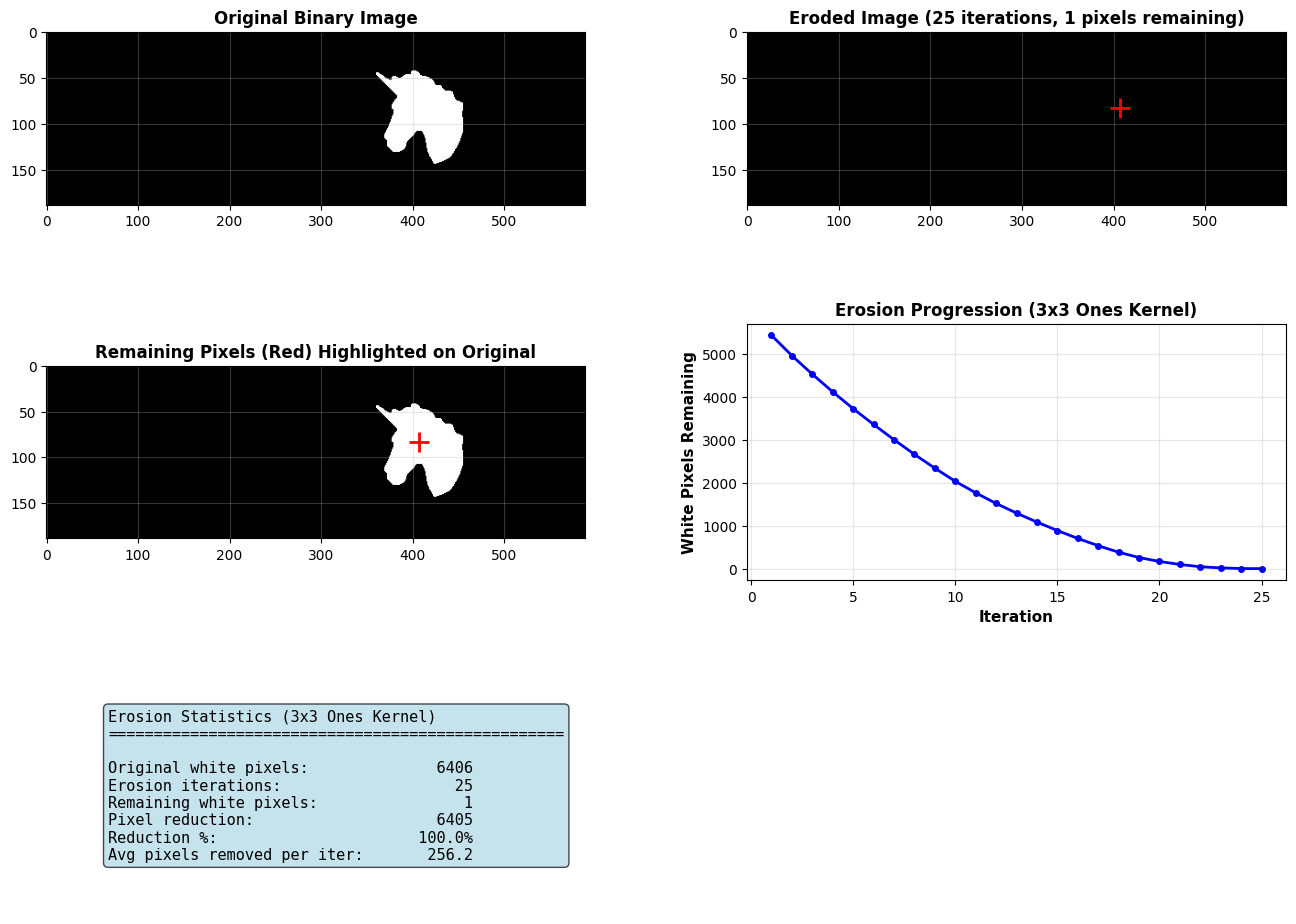

Original white pixels: 6406
Erosion iterations: 25
Remaining white pixels: 1

Kernel used: 3x3 ones (rectangular kernel - all 8 neighbors must be white to keep center pixel)


In [68]:
# Load and process the image
image_path = Path("../bin_image/einhorn_230.jpg")
original_image = load_binary_image(image_path)

# Erode until single pixel or all white pixels are gone (using 3x3 ones kernel)
eroded_image, num_erosions, erosion_history = erode_until_single_pixel(original_image)

# Visualize the result
num_remaining_pixels = visualize_erosion_result(original_image, eroded_image, num_erosions, erosion_history)

print(f"Original white pixels: {np.count_nonzero(original_image)}")
print(f"Erosion iterations: {num_erosions}")
print(f"Remaining white pixels: {num_remaining_pixels}")
print(f"\nKernel used: 3x3 ones (rectangular kernel - all 8 neighbors must be white to keep center pixel)")


## How to Use with Different Images

To process a different binary image, simply change the `image_path` variable and run the cell:

```python
# Example: Load a different image
image_path = Path("../path/to/your/image.jpg")
original_image = load_binary_image(image_path)
eroded_image, num_erosions = erode_until_single_pixel(original_image)
num_remaining_pixels = visualize_erosion_result(original_image, eroded_image, num_erosions)
```

The functions are modular and can be reused for any binary image!

In [69]:
o_image_unicorn = load_binary_image("../bin_image/einhorn_230.jpg")
o_image_cat = load_binary_image("../bin_image/katze_231.jpg")

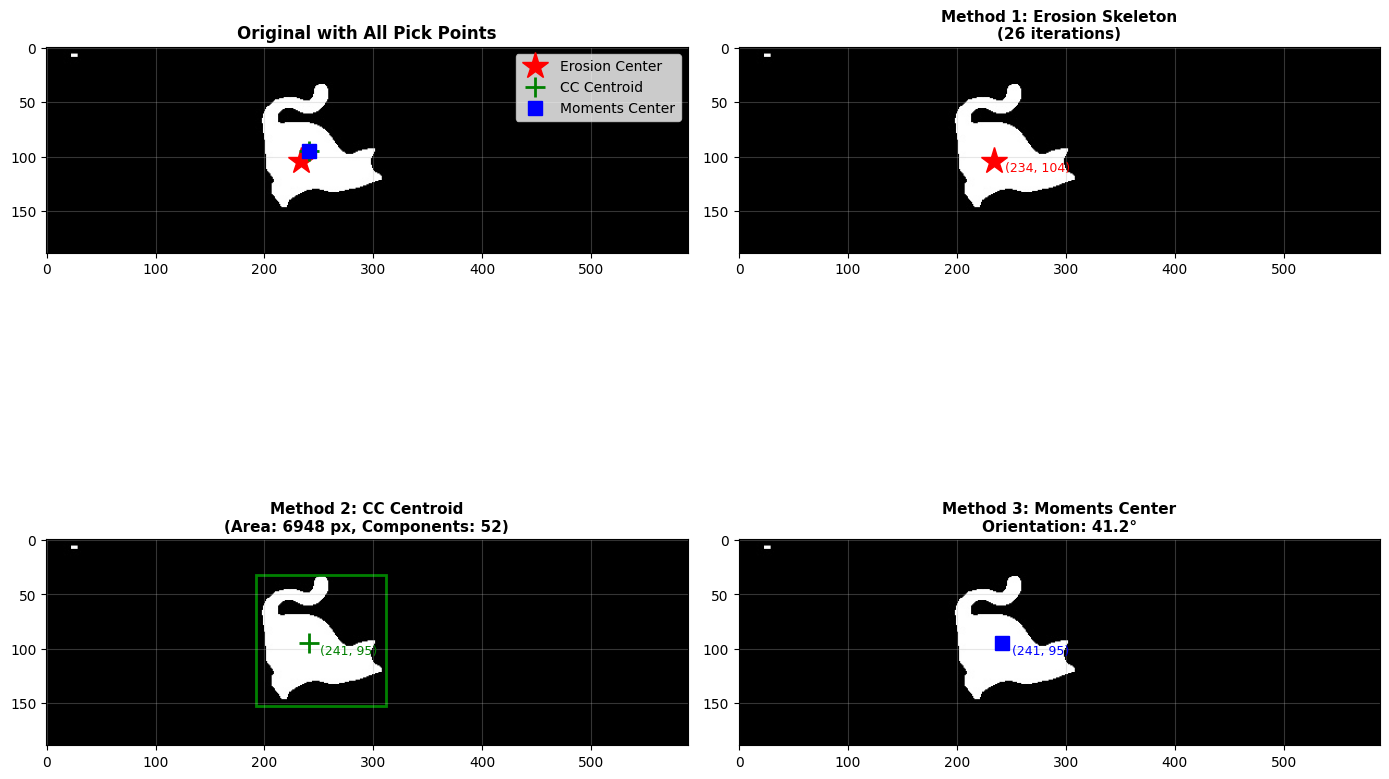

PICK POINT METHOD COMPARISON FOR PNEUMATIC GRIPPER

Method 1 - Erosion Skeleton Center:
  Pick Point: (234, 104)
  Iterations: 26
  Best for: Finding center of complex/thin shapes

Method 2 - Connected Components Centroid:
  Pick Point: (241, 95)
  Area: 6948 pixels
  Num Components: 52
  Best for: Fast, simple gripper picking

Method 3 - Moments-based Center of Mass:
  Pick Point: (241, 95)
  Orientation Angle: 41.2°
  Best for: STABLE GRIPPER CONTROL (recommended)


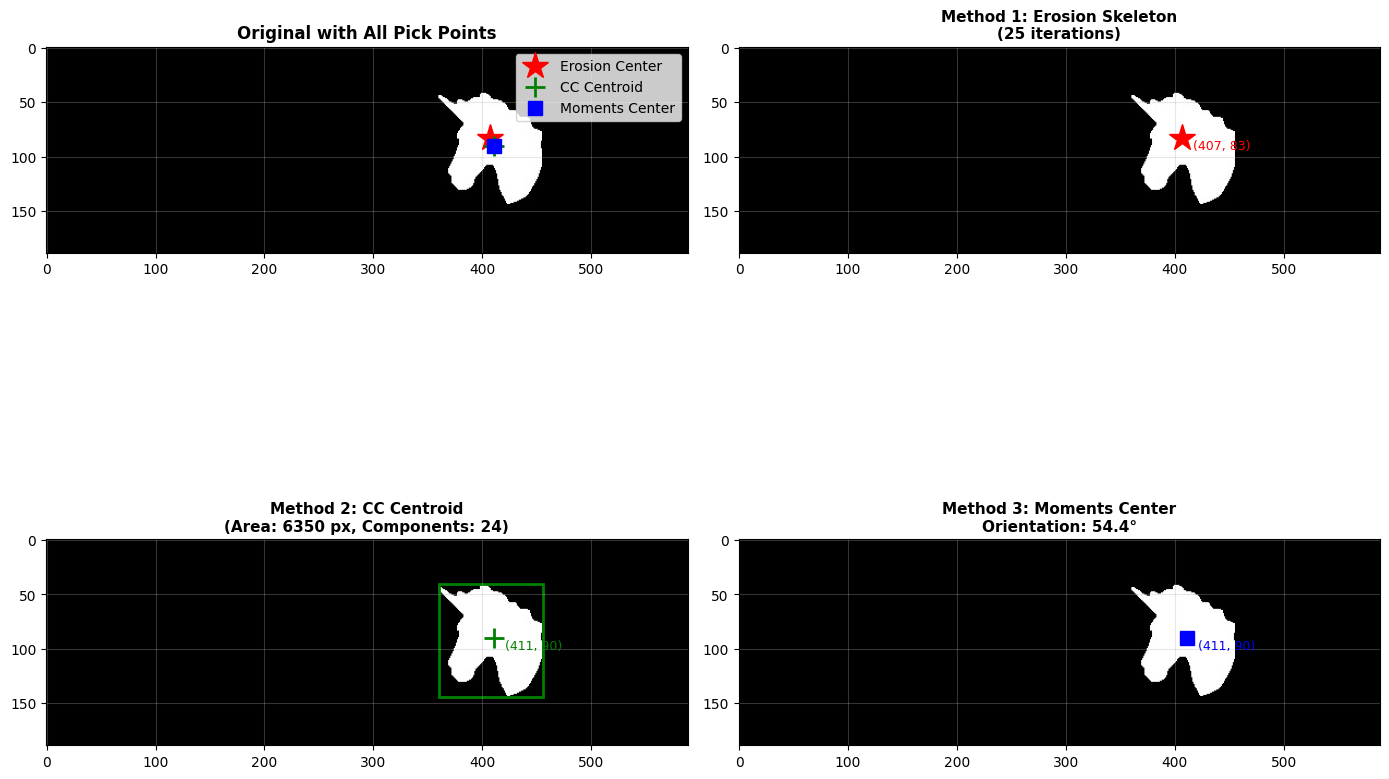

PICK POINT METHOD COMPARISON FOR PNEUMATIC GRIPPER

Method 1 - Erosion Skeleton Center:
  Pick Point: (407, 83)
  Iterations: 25
  Best for: Finding center of complex/thin shapes

Method 2 - Connected Components Centroid:
  Pick Point: (411, 90)
  Area: 6350 pixels
  Num Components: 24
  Best for: Fast, simple gripper picking

Method 3 - Moments-based Center of Mass:
  Pick Point: (411, 90)
  Orientation Angle: 54.4°
  Best for: STABLE GRIPPER CONTROL (recommended)


{'erosion': {'point': (407, 83), 'iterations': 25},
 'connected_components': {'pick_point': (411, 90),
  'area': 6350,
  'centroid': (np.float64(411.44535433070865), np.float64(90.92992125984252)),
  'bounding_rect': (np.int32(360), np.int32(40), np.int32(96), np.int32(104)),
  'num_components': 24},
 'moments': {'pick_point': (411, 90),
  'area': 6350,
  'moment_center': (411, 90),
  'orientation_angle': np.float64(54.377350491385236),
  'confidence': 'High (center of mass)'}}

In [70]:
def find_pick_point_connected_components(binary_image):
    """
    Find the optimal pick point using connected components analysis.
    This method finds the largest connected component and computes its centroid.
    
    Better for gripper picking because it directly finds the center of mass
    of the largest object, which is more stable than skeleton-based erosion.
    
    Parameters:
    -----------
    binary_image : np.ndarray
        Binary image (0 and 255)
        
    Returns:
    --------
    dict : {
        'pick_point': (x, y),
        'area': int (number of pixels in largest component),
        'centroid': (x, y),
        'bounding_rect': (x, y, w, h),
        'num_components': int
    }
    """
    # Find all connected components
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
        binary_image, connectivity=8
    )
    
    # Skip background (label 0)
    if num_labels <= 1:
        return None
    
    # Find largest component (excluding background)
    largest_idx = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
    largest_area = stats[largest_idx, cv2.CC_STAT_AREA]
    
    # Get centroid of largest component
    centroid = centroids[largest_idx]
    pick_point = (int(centroid[0]), int(centroid[1]))
    
    # Get bounding rectangle
    x = stats[largest_idx, cv2.CC_STAT_LEFT]
    y = stats[largest_idx, cv2.CC_STAT_TOP]
    w = stats[largest_idx, cv2.CC_STAT_WIDTH]
    h = stats[largest_idx, cv2.CC_STAT_HEIGHT]
    
    return {
        'pick_point': pick_point,
        'area': int(largest_area),
        'centroid': tuple(centroid),
        'bounding_rect': (x, y, w, h),
        'num_components': num_labels - 1  # Exclude background
    }


def find_pick_point_moments(binary_image):
    """
    Find the optimal pick point using image moments (center of mass).
    Uses only the largest connected component.
    
    This is mathematically the center of mass of the largest object.
    Very stable and suitable for pneumatic grippers.
    
    Parameters:
    -----------
    binary_image : np.ndarray
        Binary image (0 and 255)
        
    Returns:
    --------
    dict : {
        'pick_point': (x, y),
        'area': int,
        'moment_center': (x, y),
        'orientation_angle': float (degrees)
    }
    """
    # Find connected component
    result = find_pick_point_connected_components(binary_image)
    if result is None:
        return None
    
    # Get the largest component mask
    num_labels, labels = cv2.connectedComponents(binary_image, connectivity=8)
    if num_labels <= 1:
        return None
    
    largest_idx = 1 + np.argmax(cv2.connectedComponentsWithStats(
        binary_image, connectivity=8)[2][1:, cv2.CC_STAT_AREA])
    
    largest_component = (labels == largest_idx).astype(np.uint8) * 255
    
    # Calculate moments
    M = cv2.moments(largest_component)
    
    if M['m00'] > 0:
        cx = int(M['m10'] / M['m00'])
        cy = int(M['m01'] / M['m00'])
    else:
        cx, cy = result['pick_point']
    
    # Calculate orientation (principal axis angle)
    # Using the second order moments
    mu20 = M['mu20'] / M['m00'] if M['m00'] > 0 else 0
    mu02 = M['mu02'] / M['m00'] if M['m00'] > 0 else 0
    mu11 = M['mu11'] / M['m00'] if M['m00'] > 0 else 0
    
    if (mu20 - mu02) != 0:
        angle = 0.5 * np.arctan2(2 * mu11, mu20 - mu02)
        angle_deg = np.degrees(angle)
    else:
        angle_deg = 0.0
    
    return {
        'pick_point': (cx, cy),
        'area': result['area'],
        'moment_center': (cx, cy),
        'orientation_angle': angle_deg,
        'confidence': 'High (center of mass)'
    }


def compare_pick_point_methods(binary_image):
    """
    Compare all three pick point methods side by side.
    
    Parameters:
    -----------
    binary_image : np.ndarray
        Binary image (0 and 255)
    """
    # Method 1: Erosion-based skeleton center
    eroded, num_erosions, history = erode_until_single_pixel(binary_image)
    white_pixels = np.where(eroded > 128)
    if len(white_pixels[0]) > 0:
        erosion_point = (int(np.mean(white_pixels[1])), int(np.mean(white_pixels[0])))
    else:
        erosion_point = None
    
    # Method 2: Connected components centroid
    cc_result = find_pick_point_connected_components(binary_image)
    cc_point = cc_result['pick_point'] if cc_result else None
    
    # Method 3: Moments-based center of mass
    moments_result = find_pick_point_moments(binary_image)
    moments_point = moments_result['pick_point'] if moments_result else None
    
    # Visualize all methods
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    
    # Original with all pick points
    ax = axes[0, 0]
    ax.imshow(binary_image, cmap='gray')
    ax.set_title('Original with All Pick Points', fontsize=12, fontweight='bold')
    if erosion_point:
        ax.plot(erosion_point[0], erosion_point[1], 'r*', markersize=20, label='Erosion Center')
    if cc_point:
        ax.plot(cc_point[0], cc_point[1], 'g+', markersize=15, markeredgewidth=2, label='CC Centroid')
    if moments_point:
        ax.plot(moments_point[0], moments_point[1], 'bs', markersize=10, label='Moments Center')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Method 1: Erosion
    ax = axes[0, 1]
    ax.imshow(binary_image, cmap='gray')
    ax.set_title(f'Method 1: Erosion Skeleton\n({num_erosions} iterations)', fontsize=11, fontweight='bold')
    if erosion_point:
        ax.plot(erosion_point[0], erosion_point[1], 'r*', markersize=20)
        ax.text(erosion_point[0] + 10, erosion_point[1] + 10, f'({erosion_point[0]}, {erosion_point[1]})', 
                color='red', fontsize=9)
    ax.grid(True, alpha=0.3)
    
    # Method 2: Connected components
    ax = axes[1, 0]
    ax.imshow(binary_image, cmap='gray')
    ax.set_title(f'Method 2: CC Centroid\n(Area: {cc_result["area"] if cc_result else "N/A"} px, Components: {cc_result["num_components"] if cc_result else "N/A"})', 
                 fontsize=11, fontweight='bold')
    if cc_point:
        ax.plot(cc_point[0], cc_point[1], 'g+', markersize=15, markeredgewidth=2)
        ax.text(cc_point[0] + 10, cc_point[1] + 10, f'({cc_point[0]}, {cc_point[1]})', 
                color='green', fontsize=9)
    if cc_result:
        x, y, w, h = cc_result['bounding_rect']
        ax.add_patch(plt.Rectangle((x, y), w, h, fill=False, edgecolor='green', linewidth=2))
    ax.grid(True, alpha=0.3)
    
    # Method 3: Moments
    ax = axes[1, 1]
    ax.imshow(binary_image, cmap='gray')
    orientation_text = f"Orientation: {moments_result['orientation_angle']:.1f}°" if moments_result else ""
    ax.set_title(f'Method 3: Moments Center\n{orientation_text}', fontsize=11, fontweight='bold')
    if moments_point:
        ax.plot(moments_point[0], moments_point[1], 'bs', markersize=10)
        ax.text(moments_point[0] + 10, moments_point[1] + 10, f'({moments_point[0]}, {moments_point[1]})', 
                color='blue', fontsize=9)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print comparison
    print("=" * 70)
    print("PICK POINT METHOD COMPARISON FOR PNEUMATIC GRIPPER")
    print("=" * 70)
    print(f"\nMethod 1 - Erosion Skeleton Center:")
    print(f"  Pick Point: {erosion_point}")
    print(f"  Iterations: {num_erosions}")
    print(f"  Best for: Finding center of complex/thin shapes")
    
    print(f"\nMethod 2 - Connected Components Centroid:")
    print(f"  Pick Point: {cc_point}")
    print(f"  Area: {cc_result['area'] if cc_result else 'N/A'} pixels")
    print(f"  Num Components: {cc_result['num_components'] if cc_result else 'N/A'}")
    print(f"  Best for: Fast, simple gripper picking")
    
    print(f"\nMethod 3 - Moments-based Center of Mass:")
    print(f"  Pick Point: {moments_point}")
    print(f"  Orientation Angle: {moments_result['orientation_angle']:.1f}°" if moments_result else "N/A")
    print(f"  Best for: STABLE GRIPPER CONTROL (recommended)")
    print("=" * 70)
    
    return {
        'erosion': {'point': erosion_point, 'iterations': num_erosions},
        'connected_components': cc_result,
        'moments': moments_result
    }
compare_pick_point_methods(o_image_cat)
compare_pick_point_methods(o_image_unicorn)

22 Bild(er) gefunden:
  einhorn_230.jpg
  einhorn_231.jpg
  einhorn_232.jpg
  einhorn_233.jpg
  einhorn_234.jpg
  einhorn_235.jpg
  einhorn_236.jpg
  einhorn_237.jpg
  einhorn_238.jpg
  einhorn_239.jpg
  einhorn_240.jpg
  katze_230.jpg
  katze_231.jpg
  katze_232.jpg
  katze_233.jpg
  katze_234.jpg
  katze_235.jpg
  katze_236.jpg
  katze_237.jpg
  katze_238.jpg
  katze_239.jpg
  katze_240.jpg

▶ Verarbeite: einhorn_230.jpg
   ⏱ Erosionsdauer        : 2.02 ms


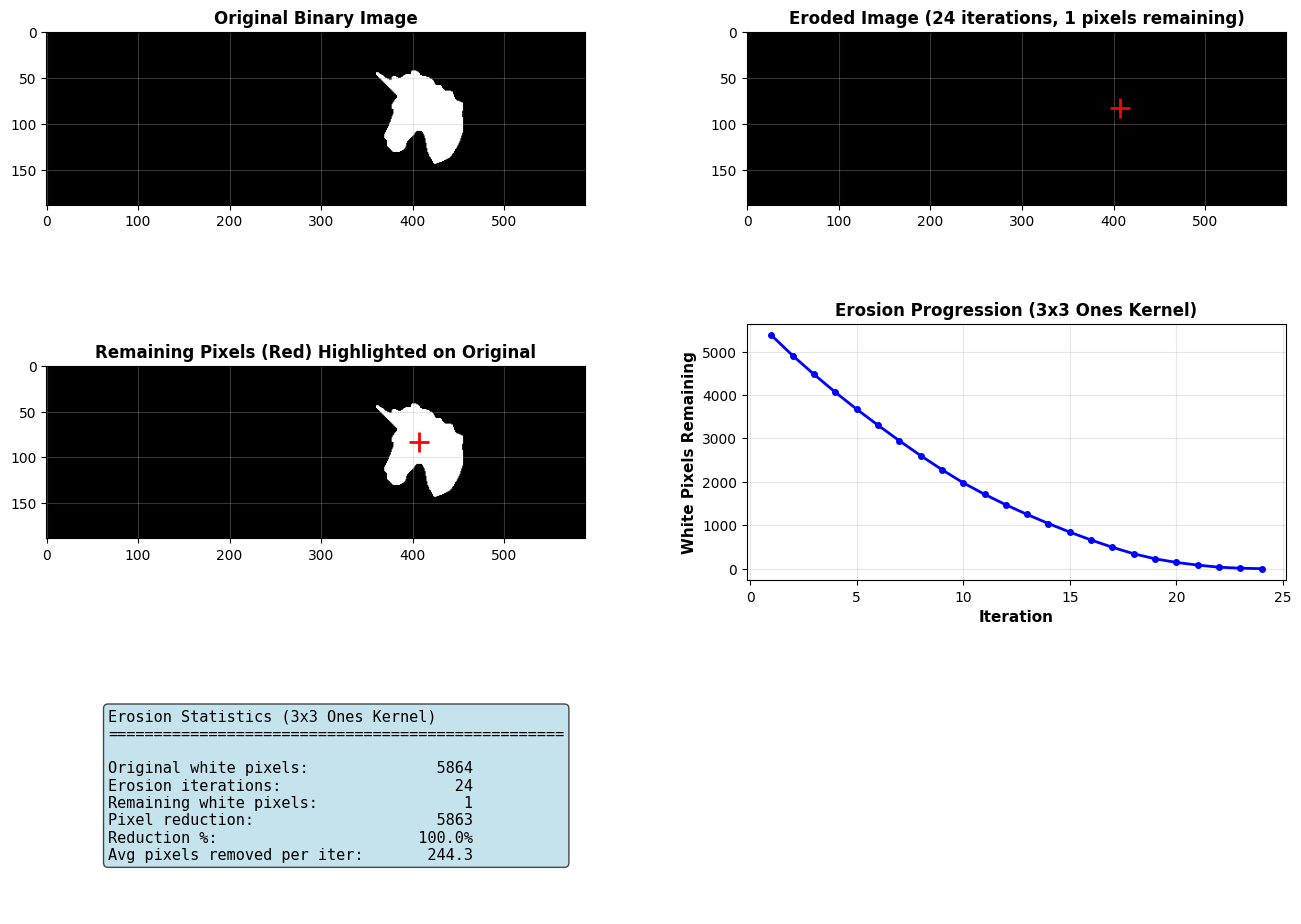

   Originale Weiß-Pixel : 5864
   Erosions-Iterationen : 24
   Verbleibende Pixel   : 1 (angezeigt: 1)
------------------------------------------------------------

▶ Verarbeite: einhorn_231.jpg
   ⏱ Erosionsdauer        : 2.69 ms
   ⚠ Alle Pixel erodiert – zeige letzten Zustand vor vollständiger Löschung.


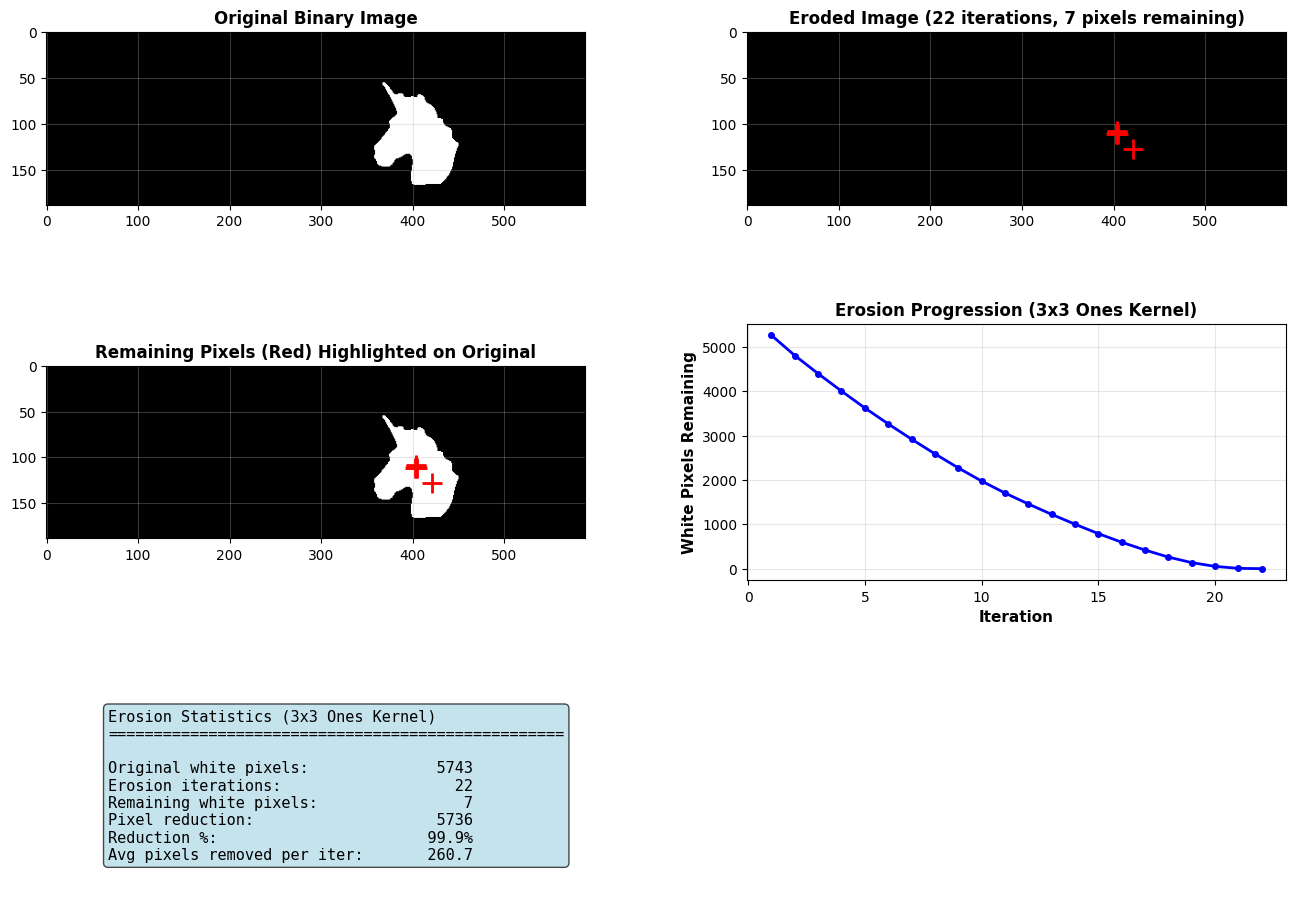

   Originale Weiß-Pixel : 5743
   Erosions-Iterationen : 22
   Verbleibende Pixel   : 0 (angezeigt: 7)
------------------------------------------------------------

▶ Verarbeite: einhorn_232.jpg
   ⏱ Erosionsdauer        : 1.35 ms
   ⚠ Alle Pixel erodiert – zeige letzten Zustand vor vollständiger Löschung.


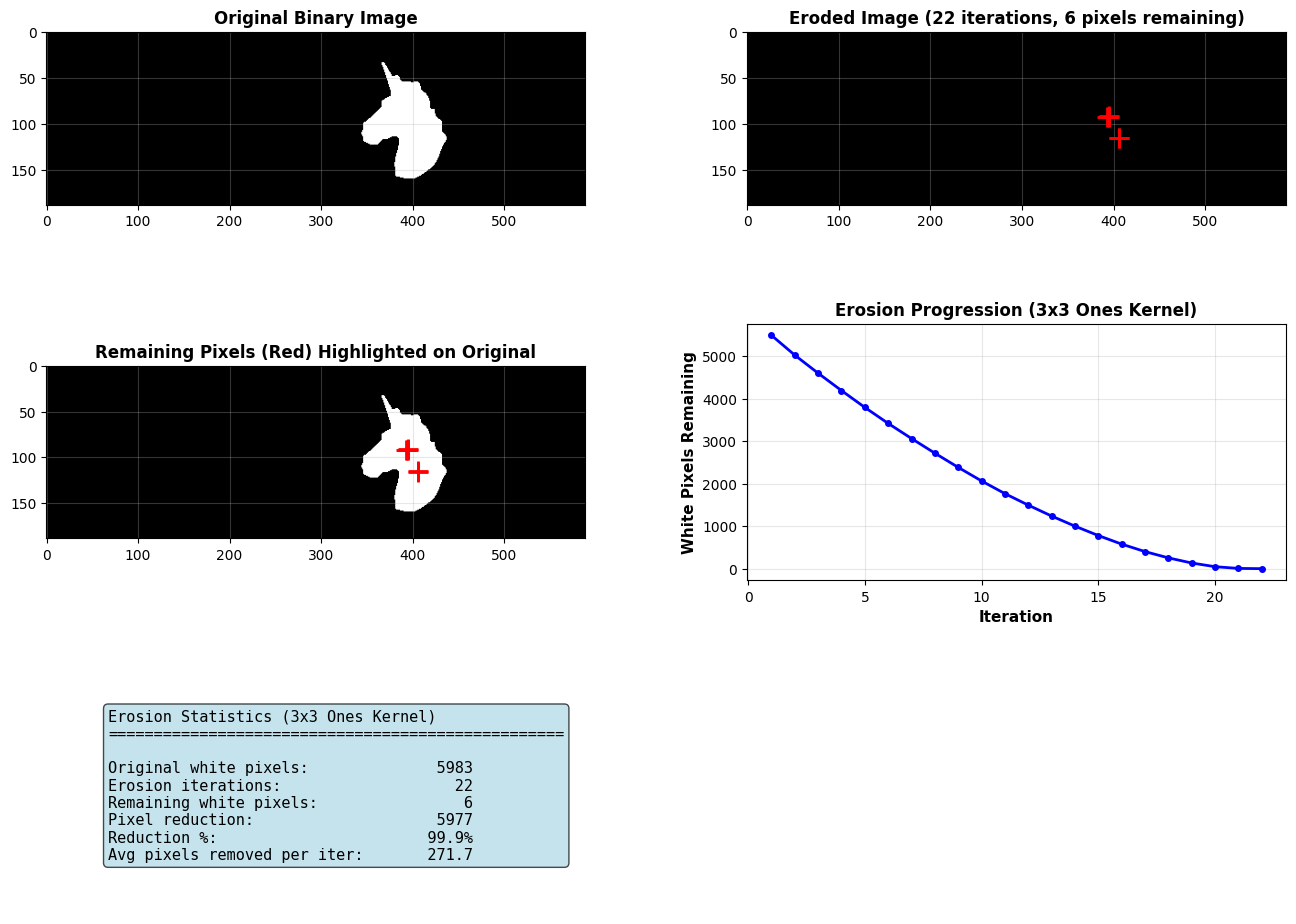

   Originale Weiß-Pixel : 5983
   Erosions-Iterationen : 22
   Verbleibende Pixel   : 0 (angezeigt: 6)
------------------------------------------------------------

▶ Verarbeite: einhorn_233.jpg
   ⏱ Erosionsdauer        : 1.34 ms
   ⚠ Alle Pixel erodiert – zeige letzten Zustand vor vollständiger Löschung.


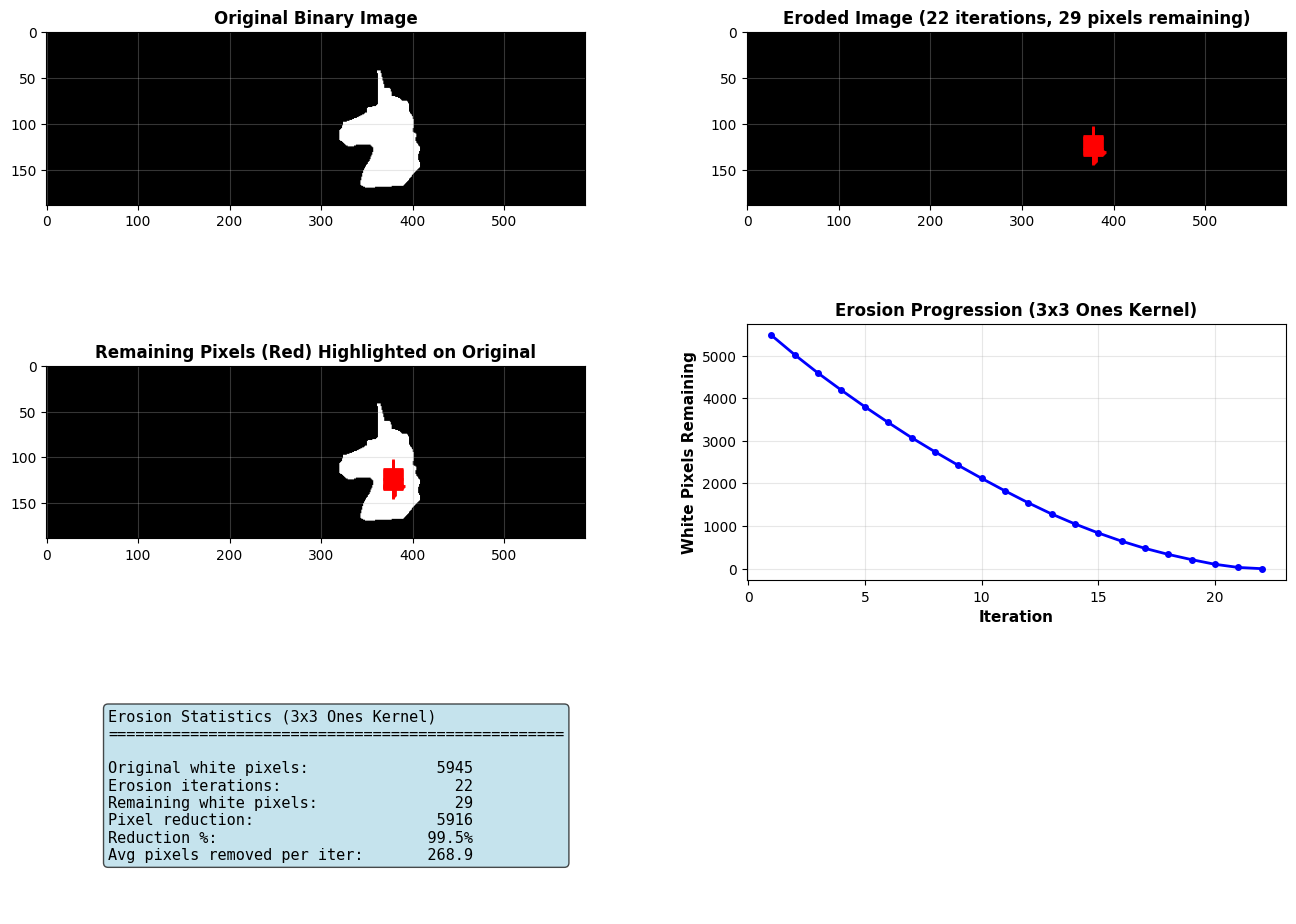

   Originale Weiß-Pixel : 5945
   Erosions-Iterationen : 22
   Verbleibende Pixel   : 0 (angezeigt: 29)
------------------------------------------------------------

▶ Verarbeite: einhorn_234.jpg
   ⏱ Erosionsdauer        : 1.71 ms
   ⚠ Alle Pixel erodiert – zeige letzten Zustand vor vollständiger Löschung.


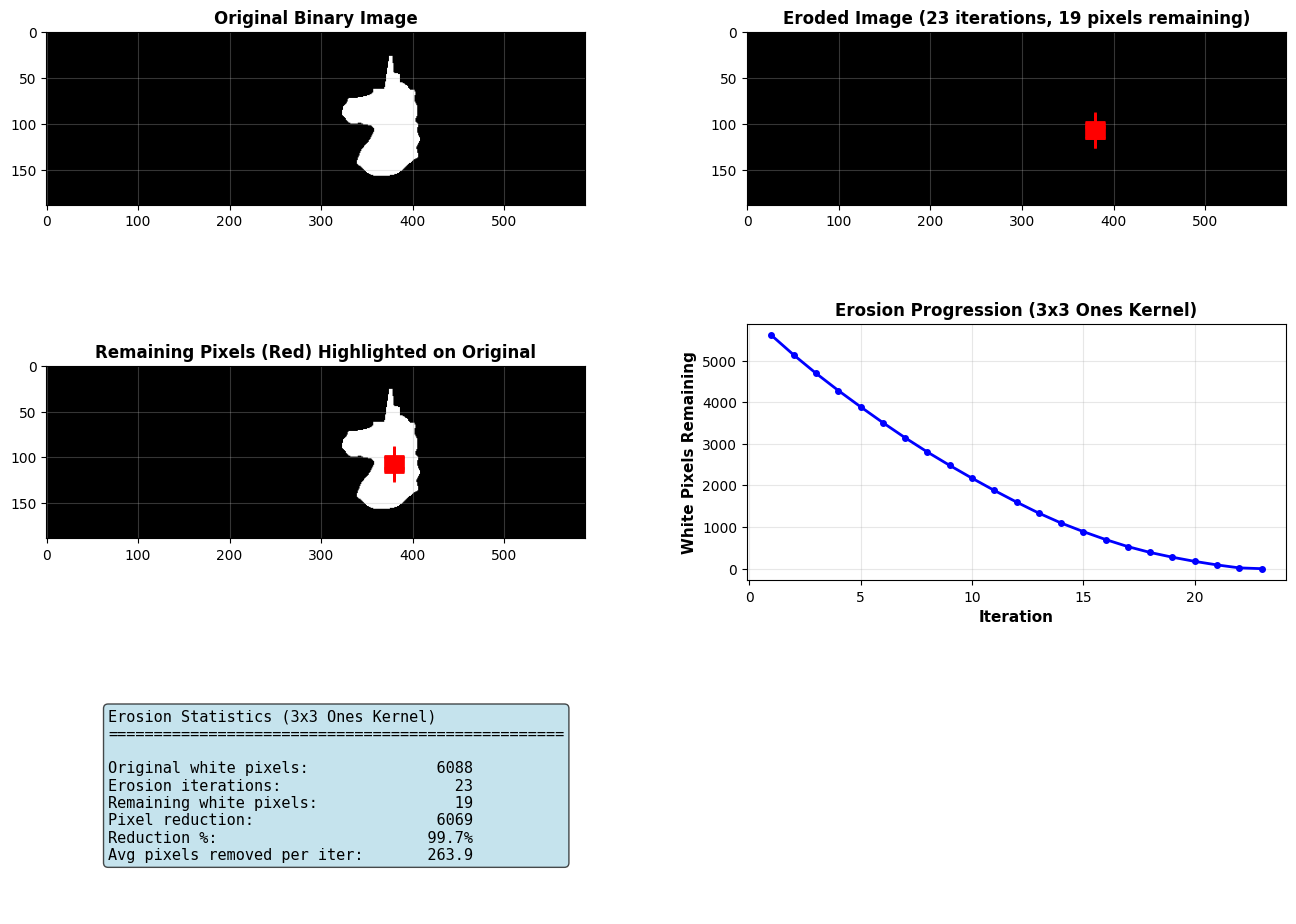

   Originale Weiß-Pixel : 6088
   Erosions-Iterationen : 23
   Verbleibende Pixel   : 0 (angezeigt: 19)
------------------------------------------------------------

▶ Verarbeite: einhorn_235.jpg
   ⏱ Erosionsdauer        : 1.49 ms
   ⚠ Alle Pixel erodiert – zeige letzten Zustand vor vollständiger Löschung.


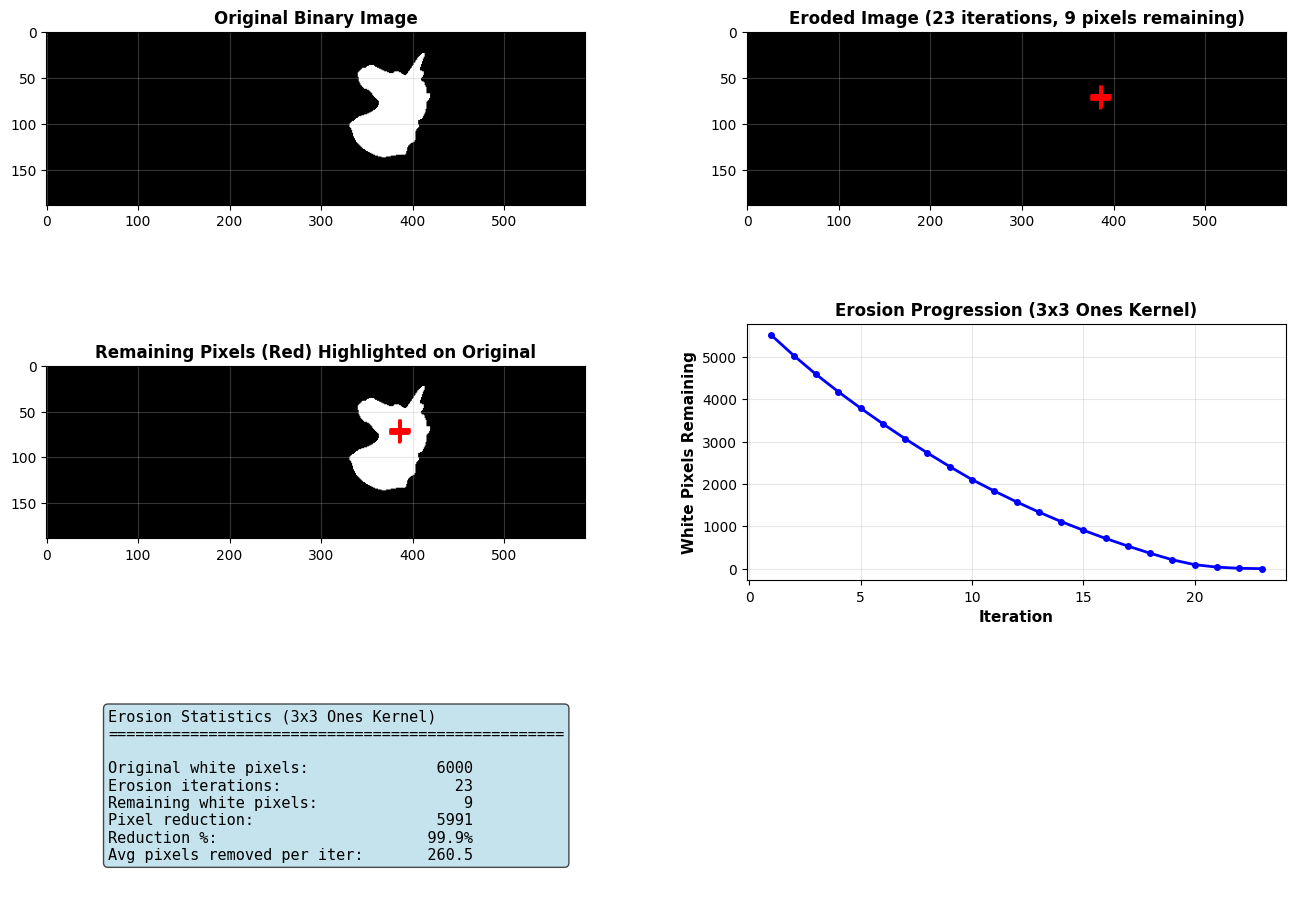

   Originale Weiß-Pixel : 6000
   Erosions-Iterationen : 23
   Verbleibende Pixel   : 0 (angezeigt: 9)
------------------------------------------------------------

▶ Verarbeite: einhorn_236.jpg
   ⏱ Erosionsdauer        : 1.53 ms
   ⚠ Alle Pixel erodiert – zeige letzten Zustand vor vollständiger Löschung.


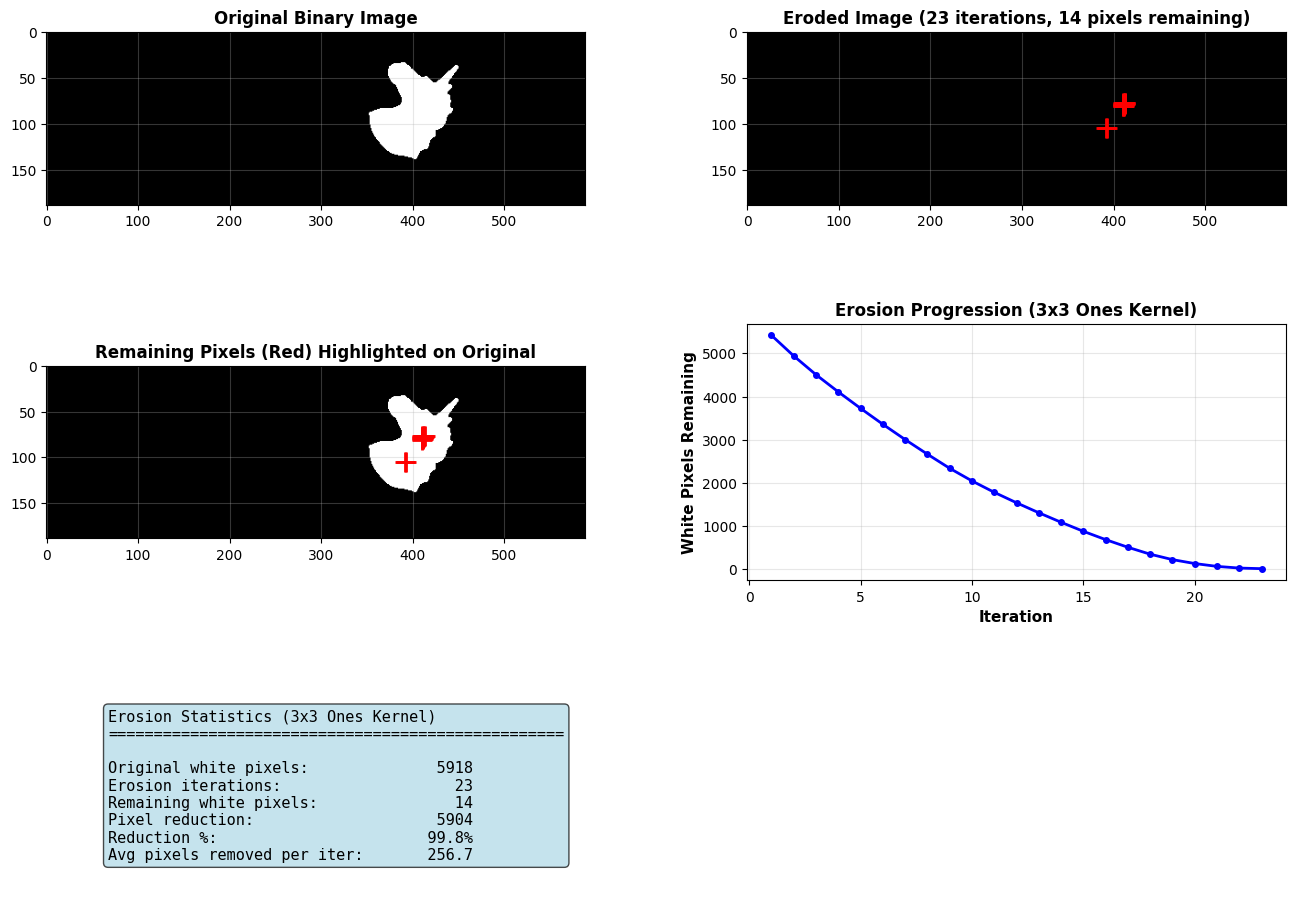

   Originale Weiß-Pixel : 5918
   Erosions-Iterationen : 23
   Verbleibende Pixel   : 0 (angezeigt: 14)
------------------------------------------------------------

▶ Verarbeite: einhorn_237.jpg
   ⏱ Erosionsdauer        : 2.06 ms


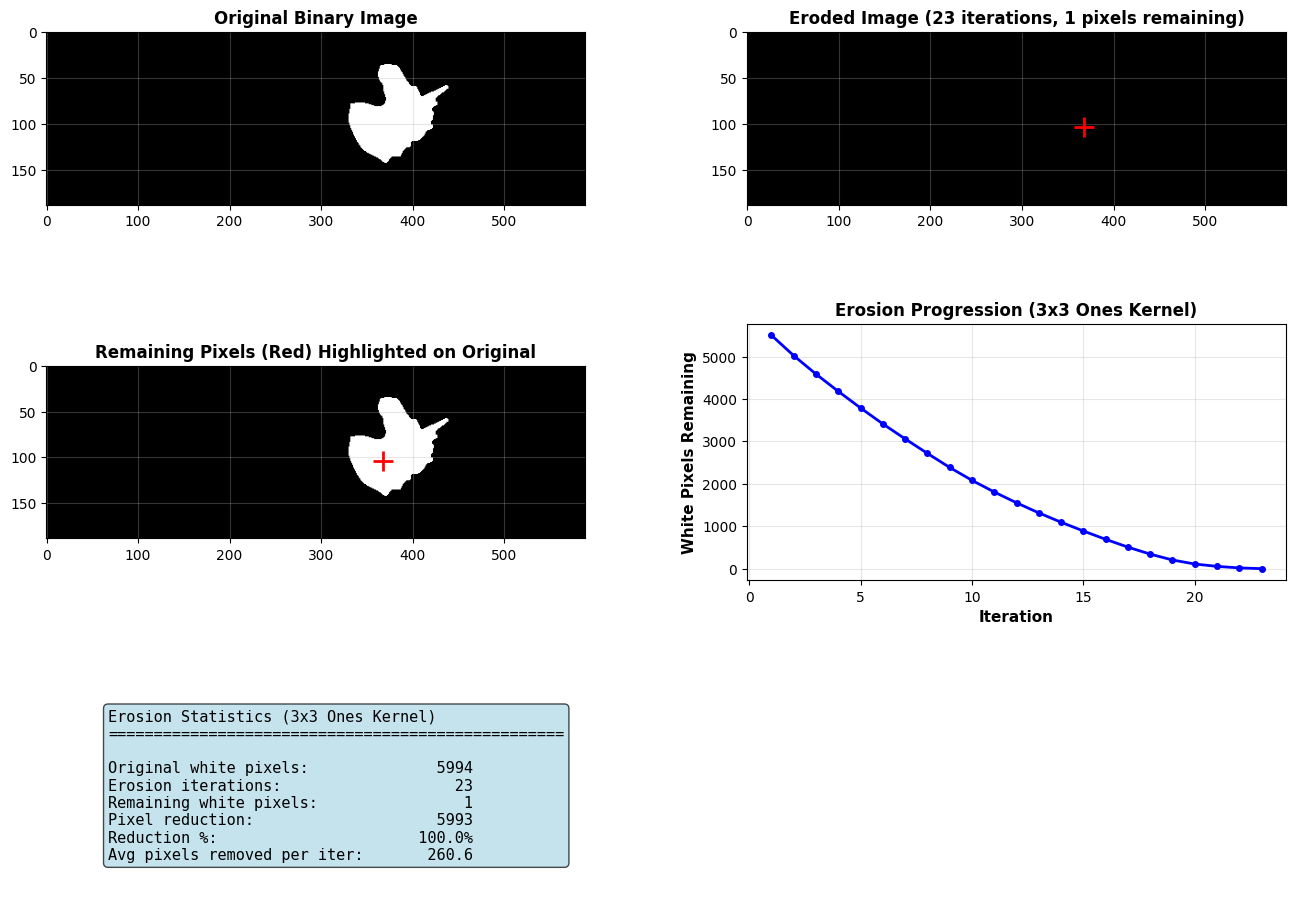

   Originale Weiß-Pixel : 5994
   Erosions-Iterationen : 23
   Verbleibende Pixel   : 1 (angezeigt: 1)
------------------------------------------------------------

▶ Verarbeite: einhorn_238.jpg
   ⏱ Erosionsdauer        : 1.80 ms
   ⚠ Alle Pixel erodiert – zeige letzten Zustand vor vollständiger Löschung.


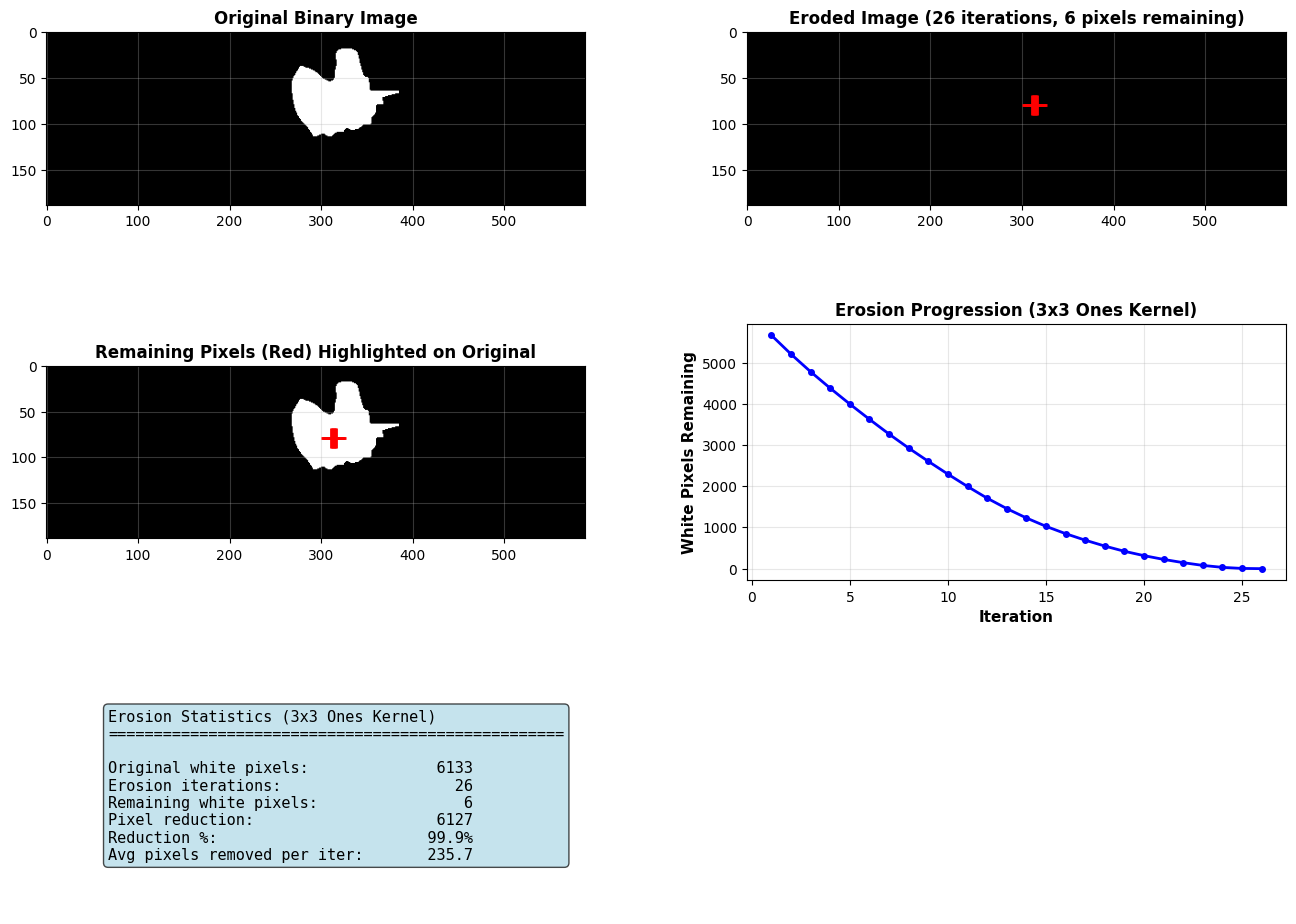

   Originale Weiß-Pixel : 6133
   Erosions-Iterationen : 26
   Verbleibende Pixel   : 0 (angezeigt: 6)
------------------------------------------------------------

▶ Verarbeite: einhorn_239.jpg
   ⏱ Erosionsdauer        : 7.51 ms
   ⚠ Alle Pixel erodiert – zeige letzten Zustand vor vollständiger Löschung.


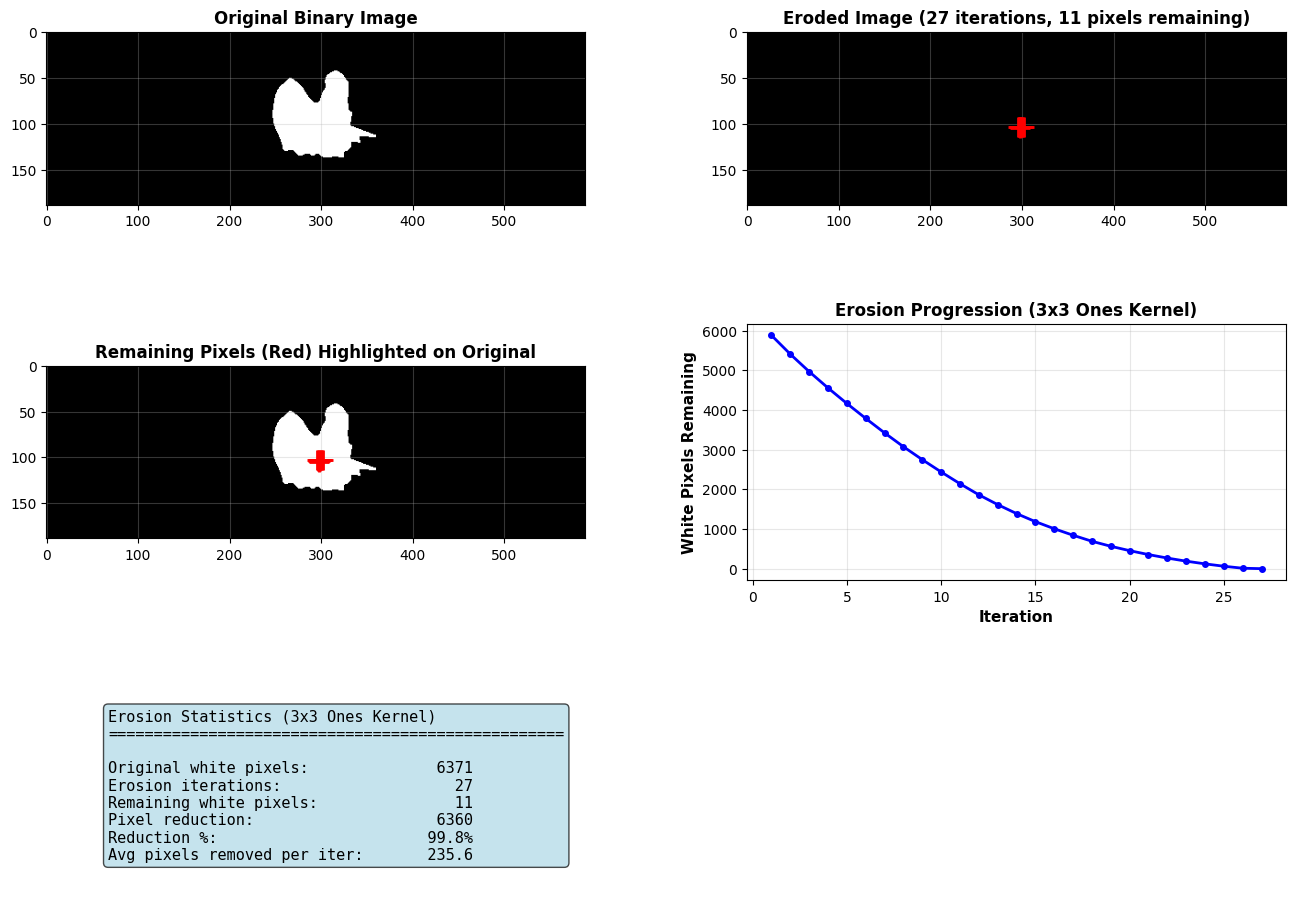

   Originale Weiß-Pixel : 6371
   Erosions-Iterationen : 27
   Verbleibende Pixel   : 0 (angezeigt: 11)
------------------------------------------------------------

▶ Verarbeite: einhorn_240.jpg
   ⏱ Erosionsdauer        : 1.95 ms
   ⚠ Alle Pixel erodiert – zeige letzten Zustand vor vollständiger Löschung.


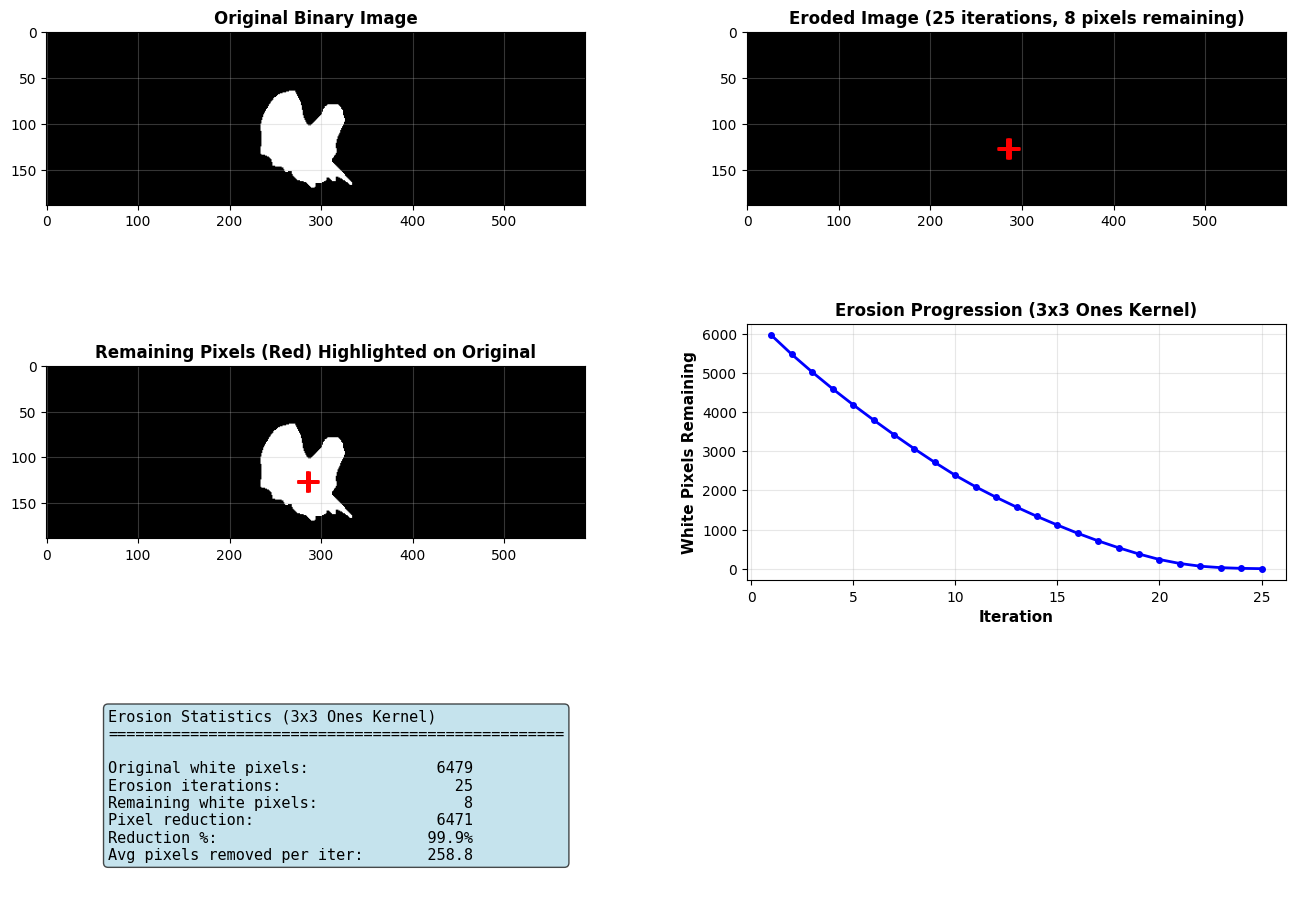

   Originale Weiß-Pixel : 6479
   Erosions-Iterationen : 25
   Verbleibende Pixel   : 0 (angezeigt: 8)
------------------------------------------------------------

▶ Verarbeite: katze_230.jpg
   ⏱ Erosionsdauer        : 1.69 ms
   ⚠ Alle Pixel erodiert – zeige letzten Zustand vor vollständiger Löschung.


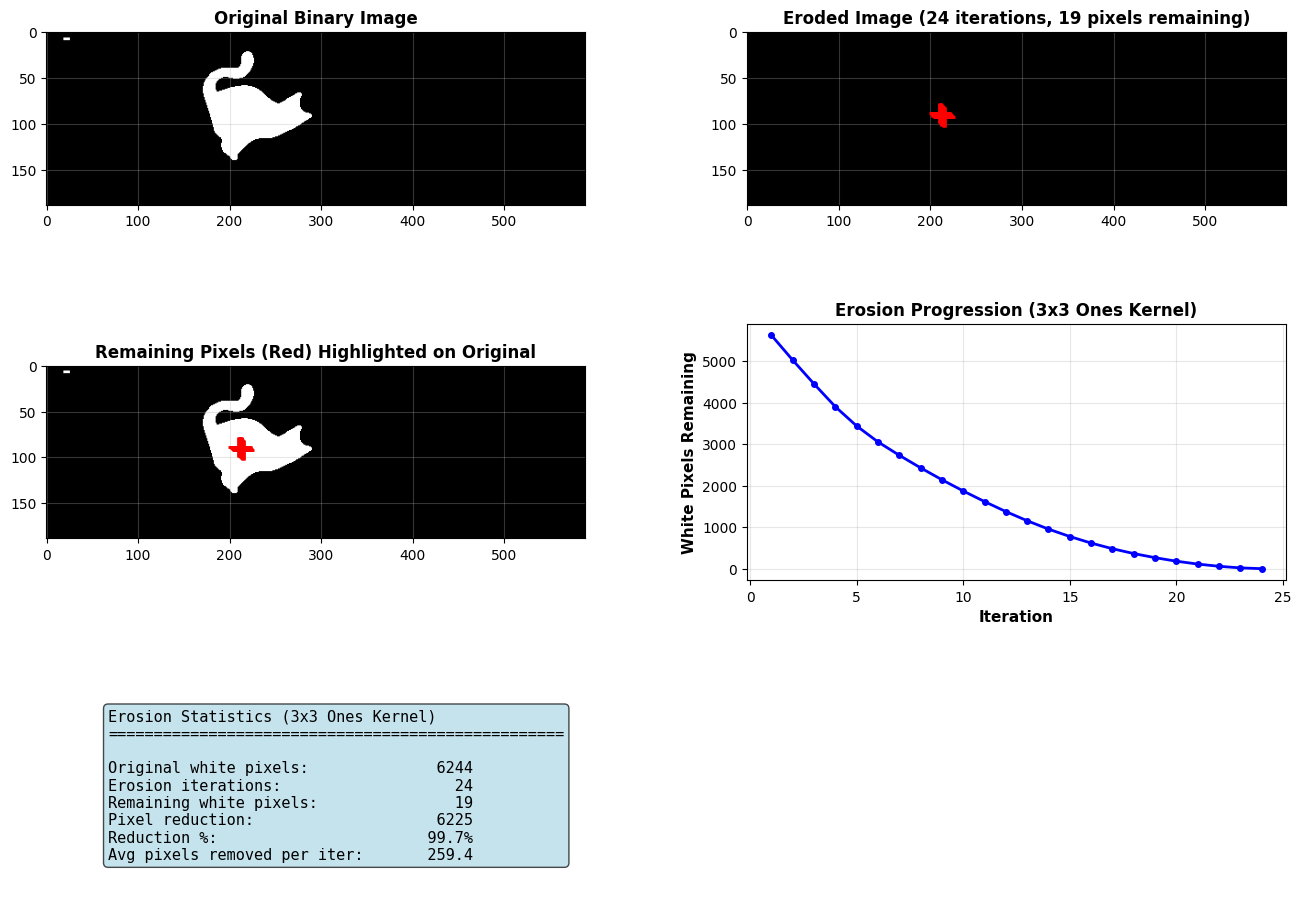

   Originale Weiß-Pixel : 6244
   Erosions-Iterationen : 24
   Verbleibende Pixel   : 0 (angezeigt: 19)
------------------------------------------------------------

▶ Verarbeite: katze_231.jpg
   ⏱ Erosionsdauer        : 2.16 ms


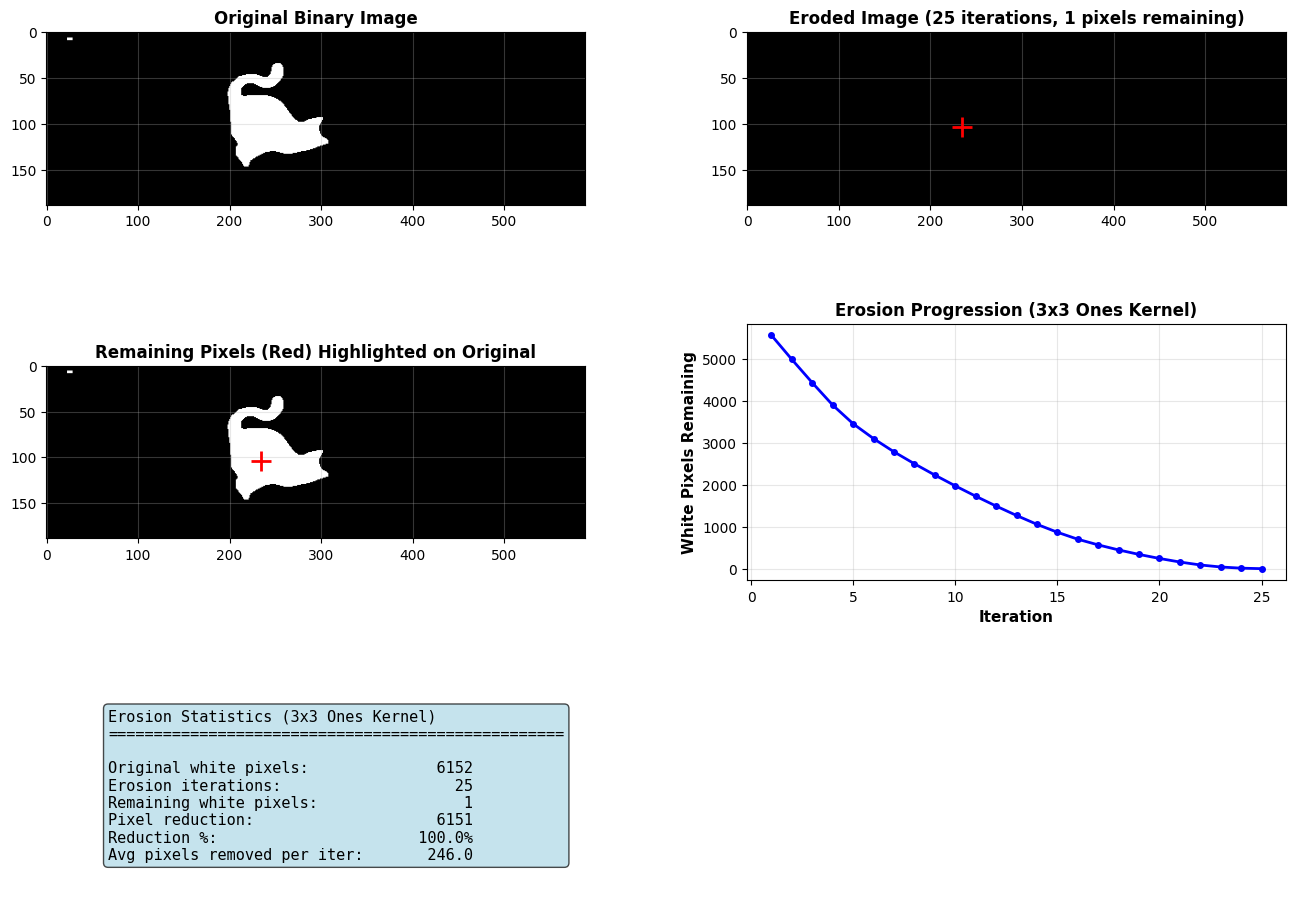

   Originale Weiß-Pixel : 6152
   Erosions-Iterationen : 25
   Verbleibende Pixel   : 1 (angezeigt: 1)
------------------------------------------------------------

▶ Verarbeite: katze_232.jpg
   ⏱ Erosionsdauer        : 2.10 ms
   ⚠ Alle Pixel erodiert – zeige letzten Zustand vor vollständiger Löschung.


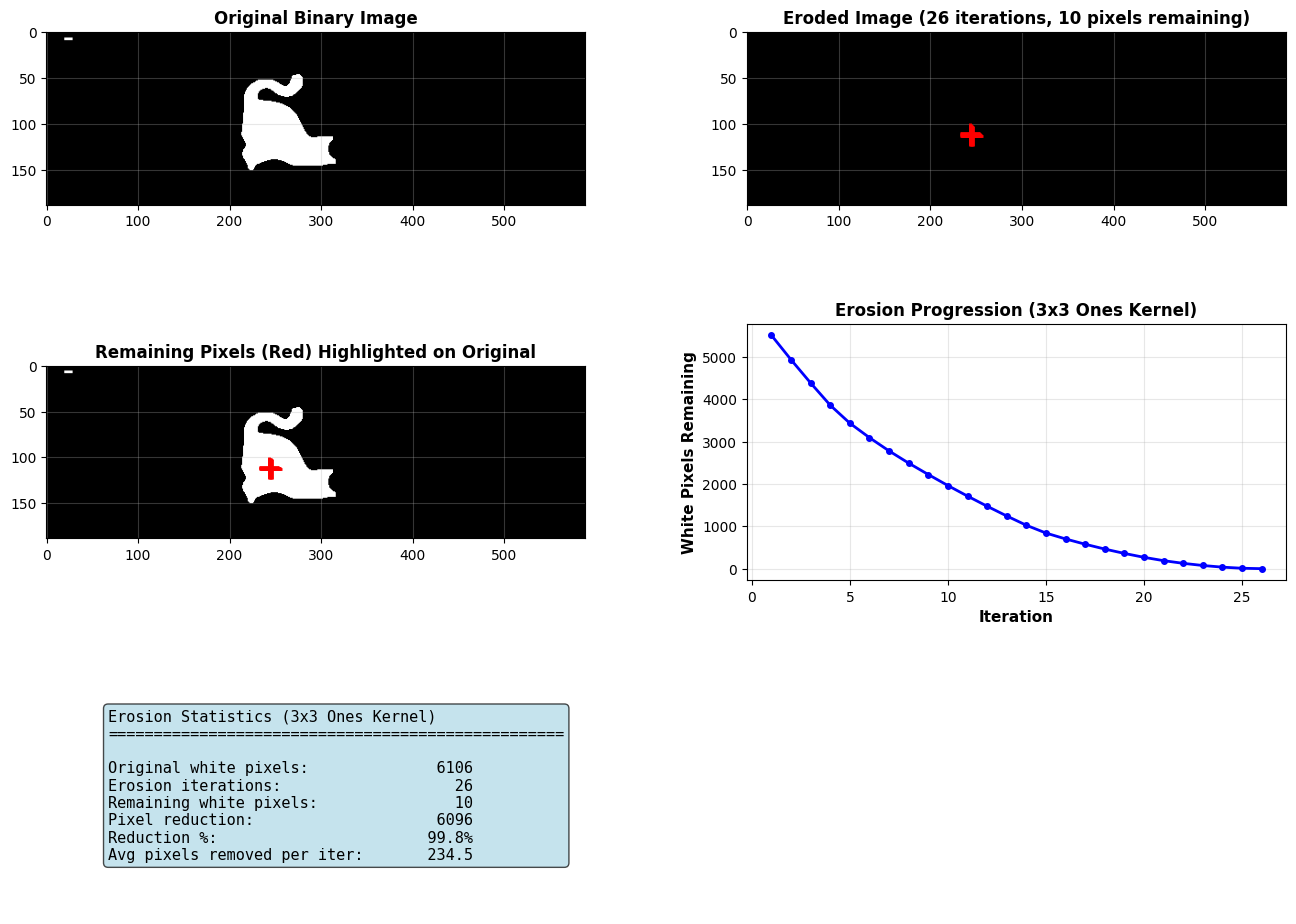

   Originale Weiß-Pixel : 6106
   Erosions-Iterationen : 26
   Verbleibende Pixel   : 0 (angezeigt: 10)
------------------------------------------------------------

▶ Verarbeite: katze_233.jpg
   ⏱ Erosionsdauer        : 2.65 ms
   ⚠ Alle Pixel erodiert – zeige letzten Zustand vor vollständiger Löschung.


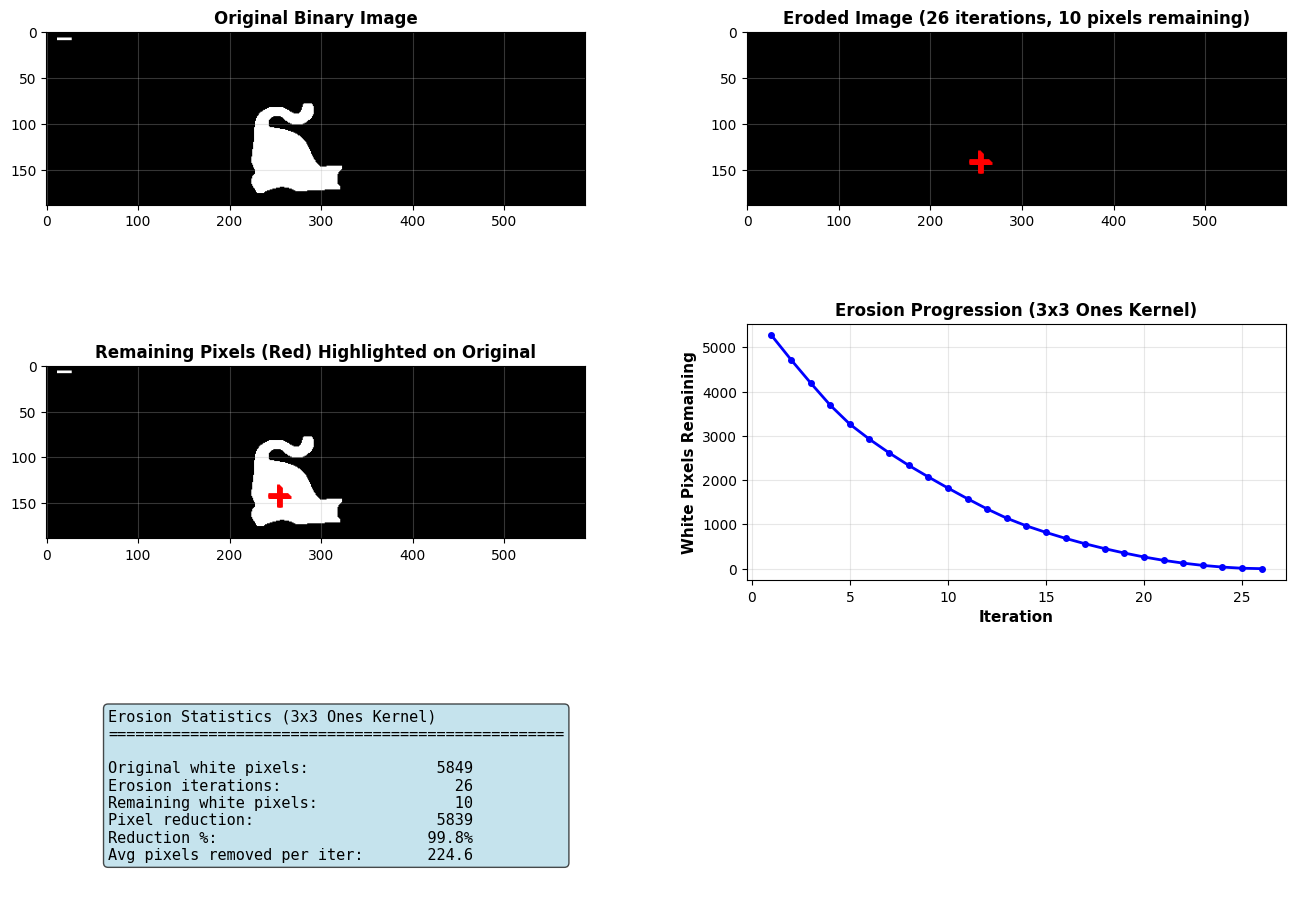

   Originale Weiß-Pixel : 5849
   Erosions-Iterationen : 26
   Verbleibende Pixel   : 0 (angezeigt: 10)
------------------------------------------------------------

▶ Verarbeite: katze_234.jpg
   ⏱ Erosionsdauer        : 1.81 ms
   ⚠ Alle Pixel erodiert – zeige letzten Zustand vor vollständiger Löschung.


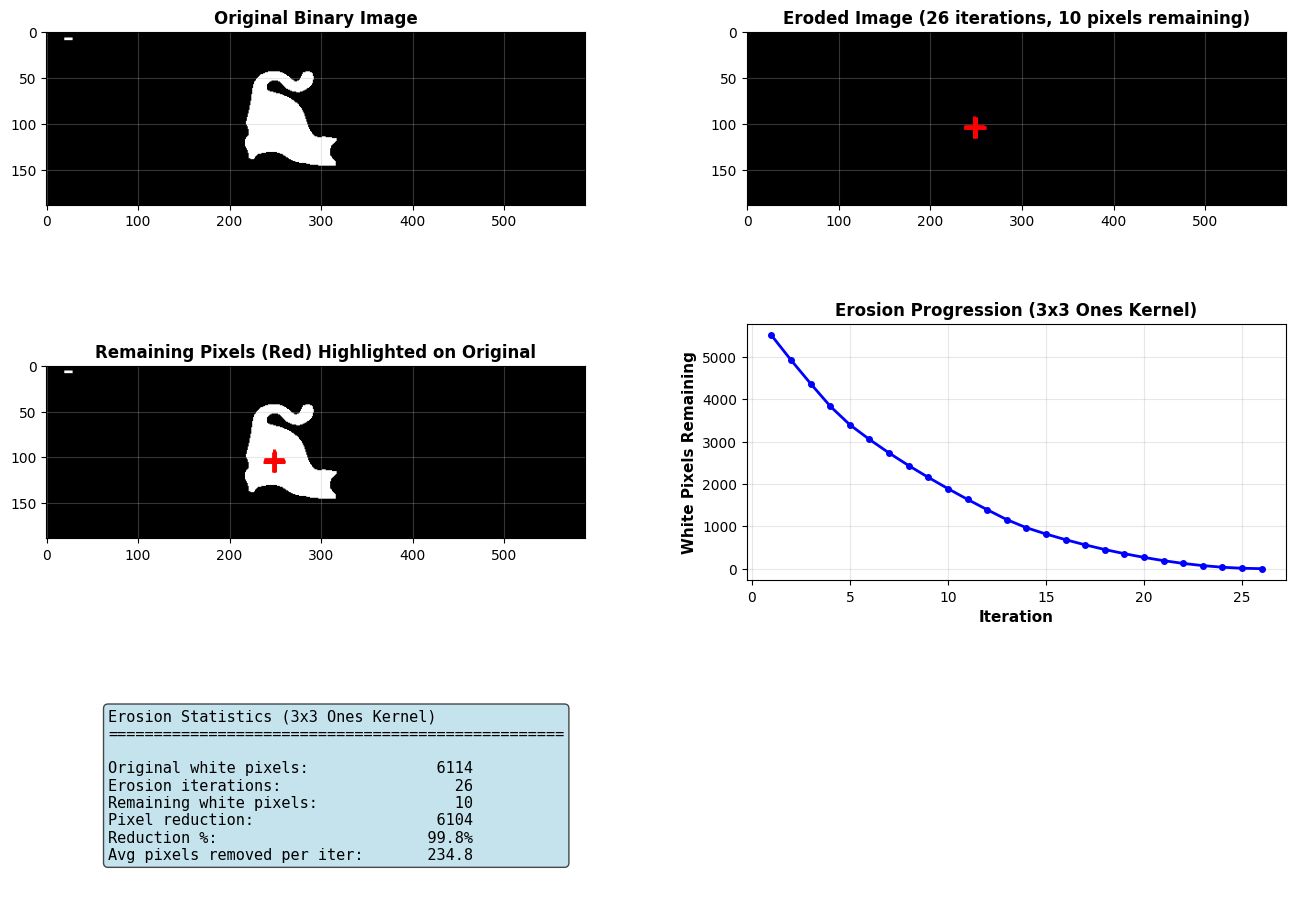

   Originale Weiß-Pixel : 6114
   Erosions-Iterationen : 26
   Verbleibende Pixel   : 0 (angezeigt: 10)
------------------------------------------------------------

▶ Verarbeite: katze_235.jpg
   ⏱ Erosionsdauer        : 1.35 ms
   ⚠ Alle Pixel erodiert – zeige letzten Zustand vor vollständiger Löschung.


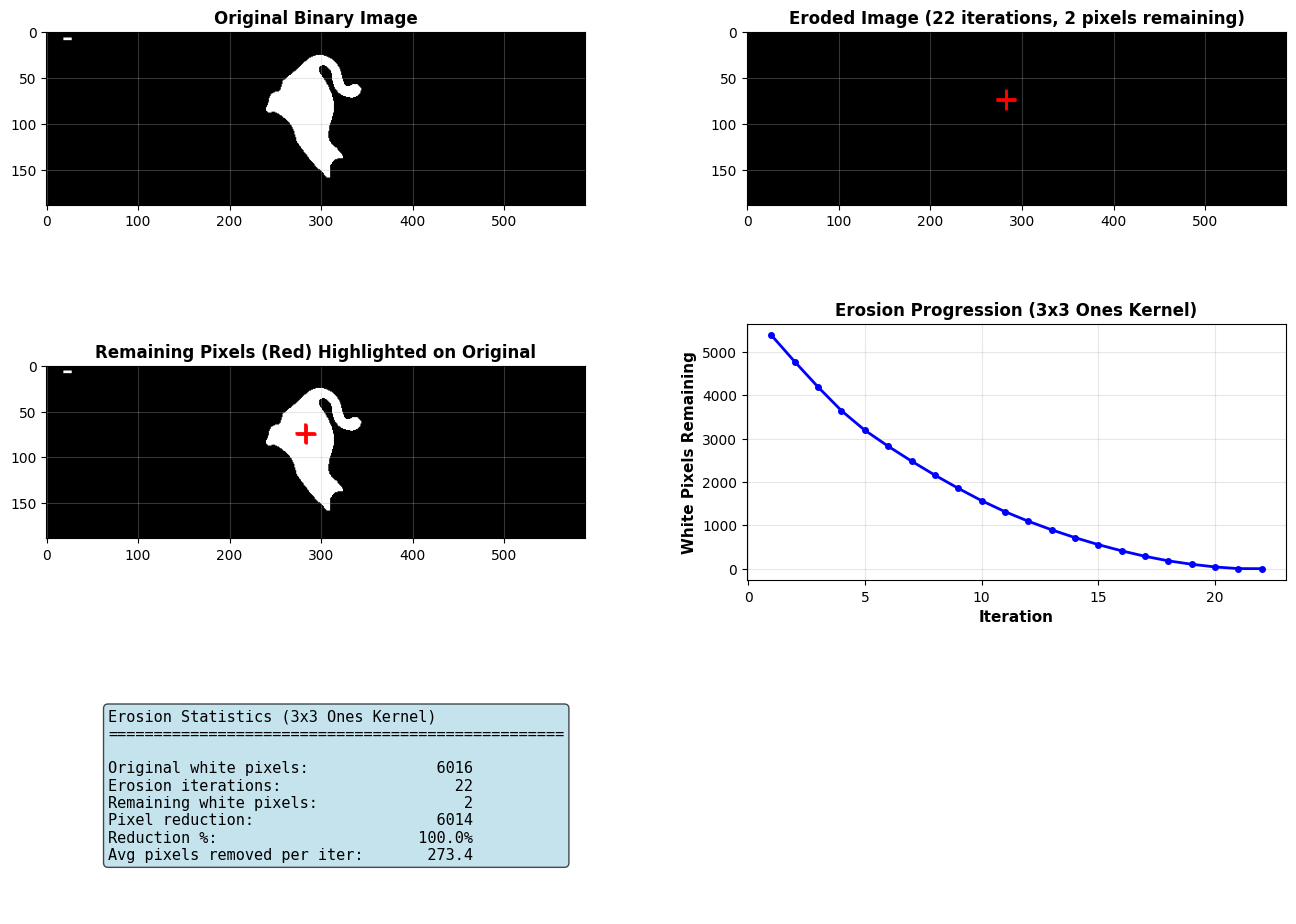

   Originale Weiß-Pixel : 6016
   Erosions-Iterationen : 22
   Verbleibende Pixel   : 0 (angezeigt: 2)
------------------------------------------------------------

▶ Verarbeite: katze_236.jpg
   ⏱ Erosionsdauer        : 1.39 ms
   ⚠ Alle Pixel erodiert – zeige letzten Zustand vor vollständiger Löschung.


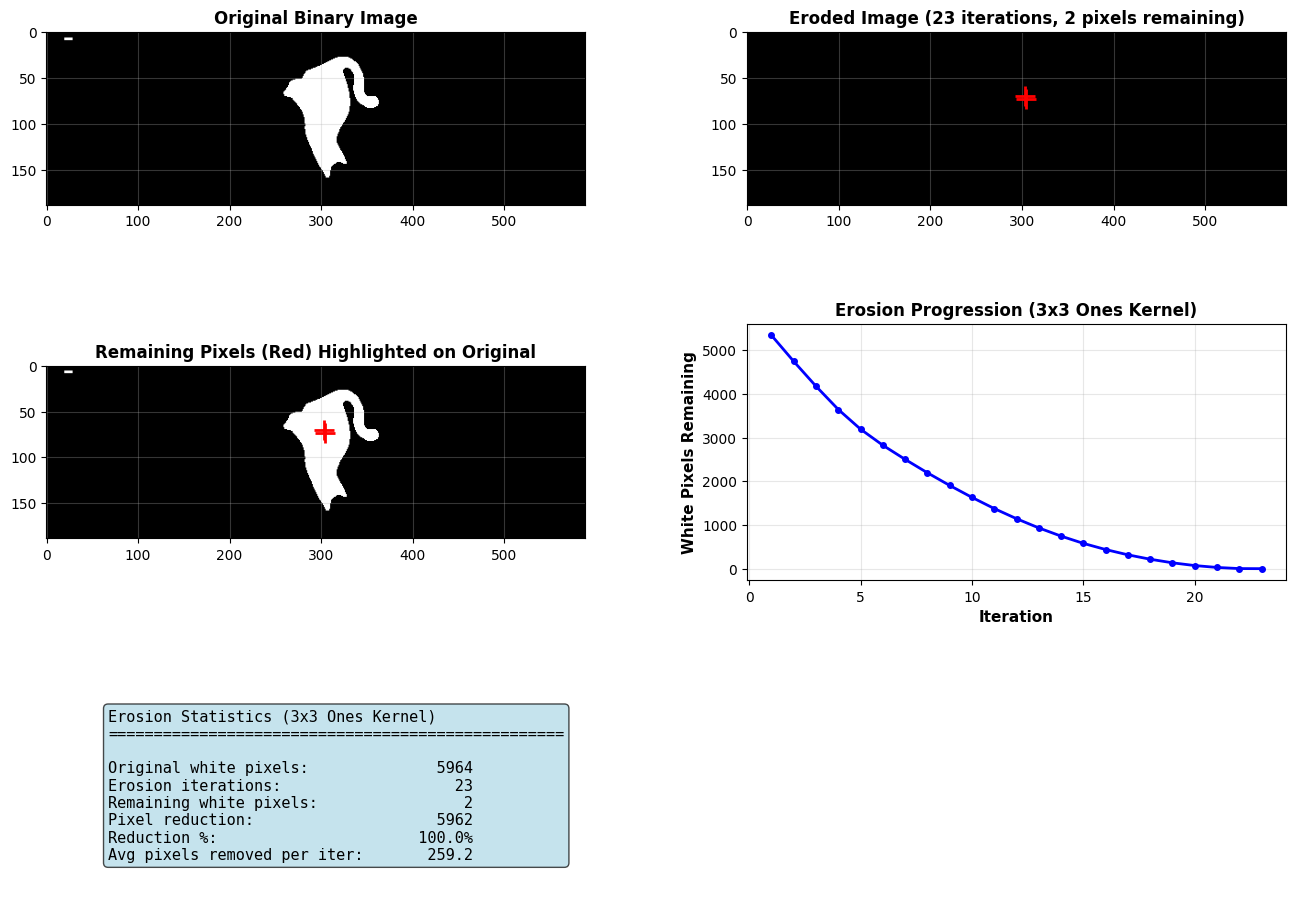

   Originale Weiß-Pixel : 5964
   Erosions-Iterationen : 23
   Verbleibende Pixel   : 0 (angezeigt: 2)
------------------------------------------------------------

▶ Verarbeite: katze_237.jpg
   ⏱ Erosionsdauer        : 3.86 ms
   ⚠ Alle Pixel erodiert – zeige letzten Zustand vor vollständiger Löschung.


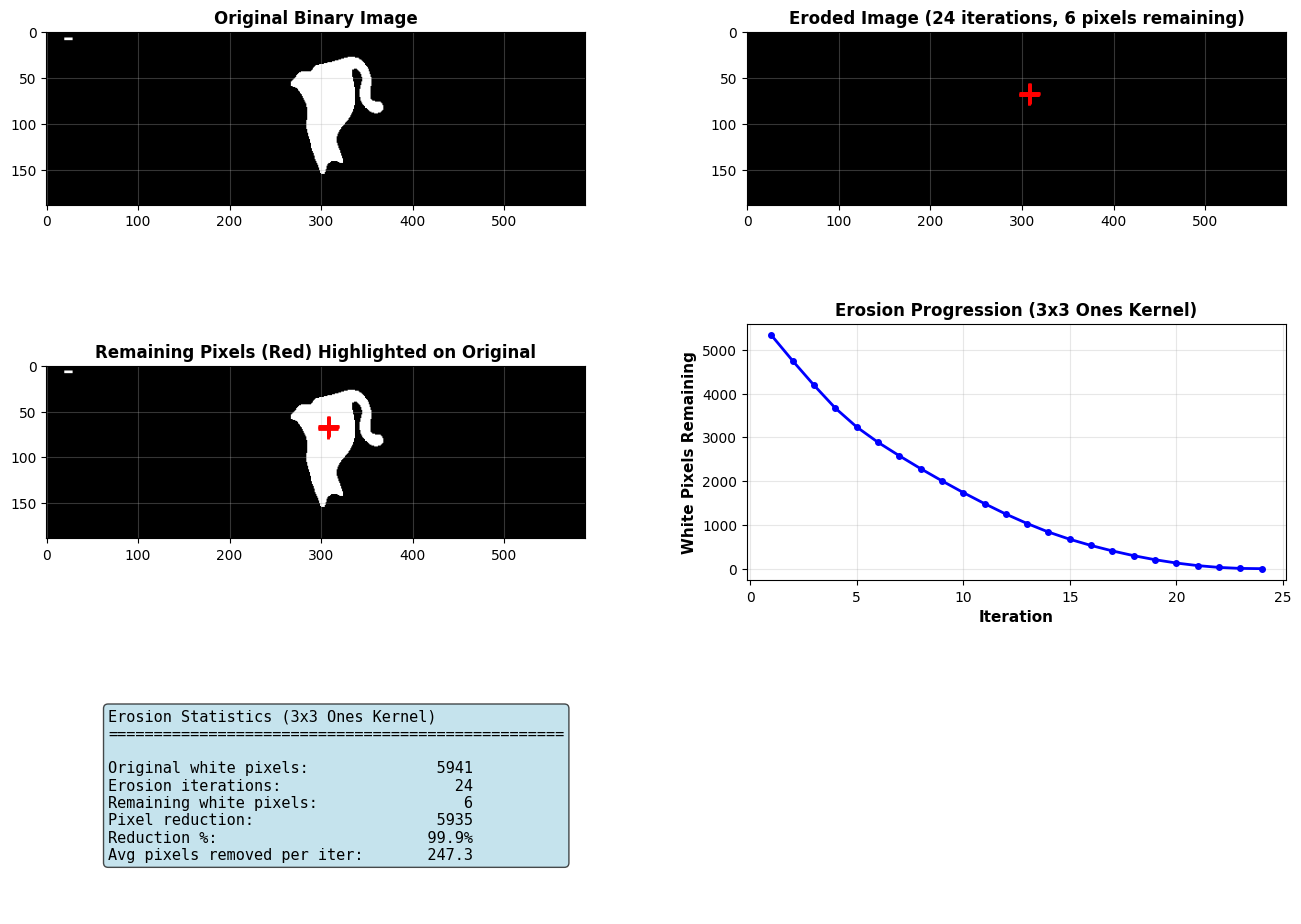

   Originale Weiß-Pixel : 5941
   Erosions-Iterationen : 24
   Verbleibende Pixel   : 0 (angezeigt: 6)
------------------------------------------------------------

▶ Verarbeite: katze_238.jpg
   ⏱ Erosionsdauer        : 3.34 ms
   ⚠ Alle Pixel erodiert – zeige letzten Zustand vor vollständiger Löschung.


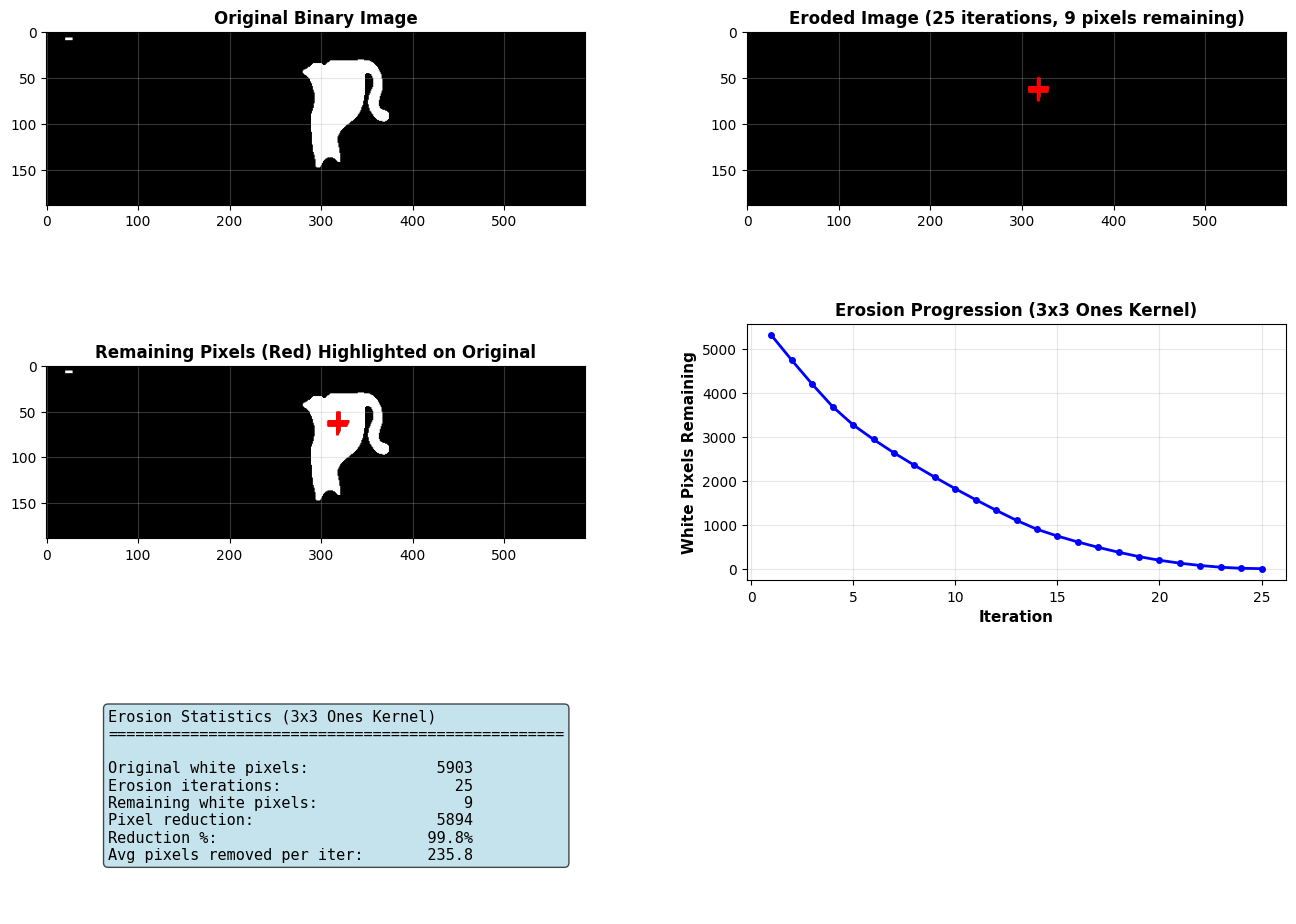

   Originale Weiß-Pixel : 5903
   Erosions-Iterationen : 25
   Verbleibende Pixel   : 0 (angezeigt: 9)
------------------------------------------------------------

▶ Verarbeite: katze_239.jpg
   ⏱ Erosionsdauer        : 1.66 ms
   ⚠ Alle Pixel erodiert – zeige letzten Zustand vor vollständiger Löschung.


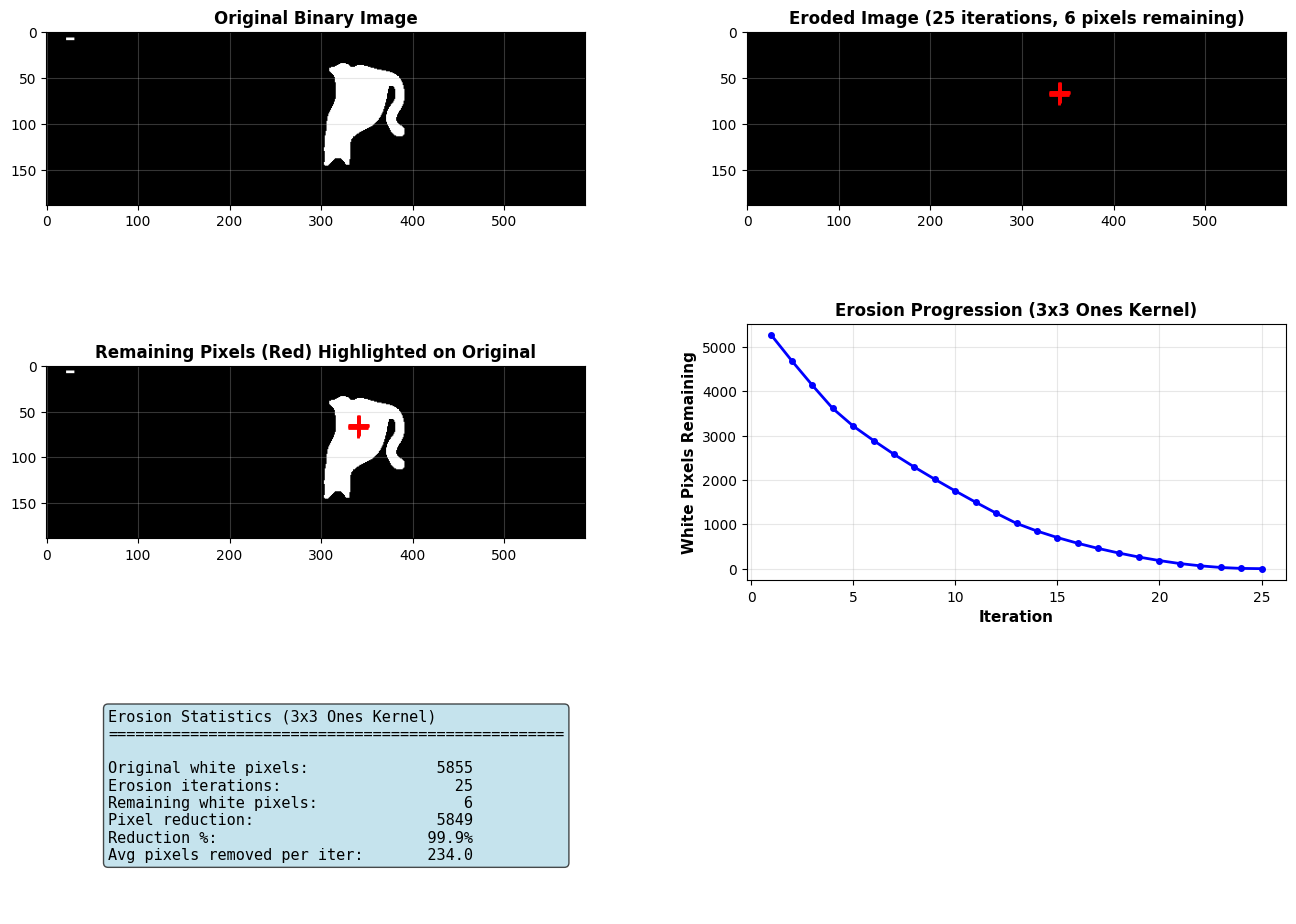

   Originale Weiß-Pixel : 5855
   Erosions-Iterationen : 25
   Verbleibende Pixel   : 0 (angezeigt: 6)
------------------------------------------------------------

▶ Verarbeite: katze_240.jpg
   ⏱ Erosionsdauer        : 2.14 ms
   ⚠ Alle Pixel erodiert – zeige letzten Zustand vor vollständiger Löschung.


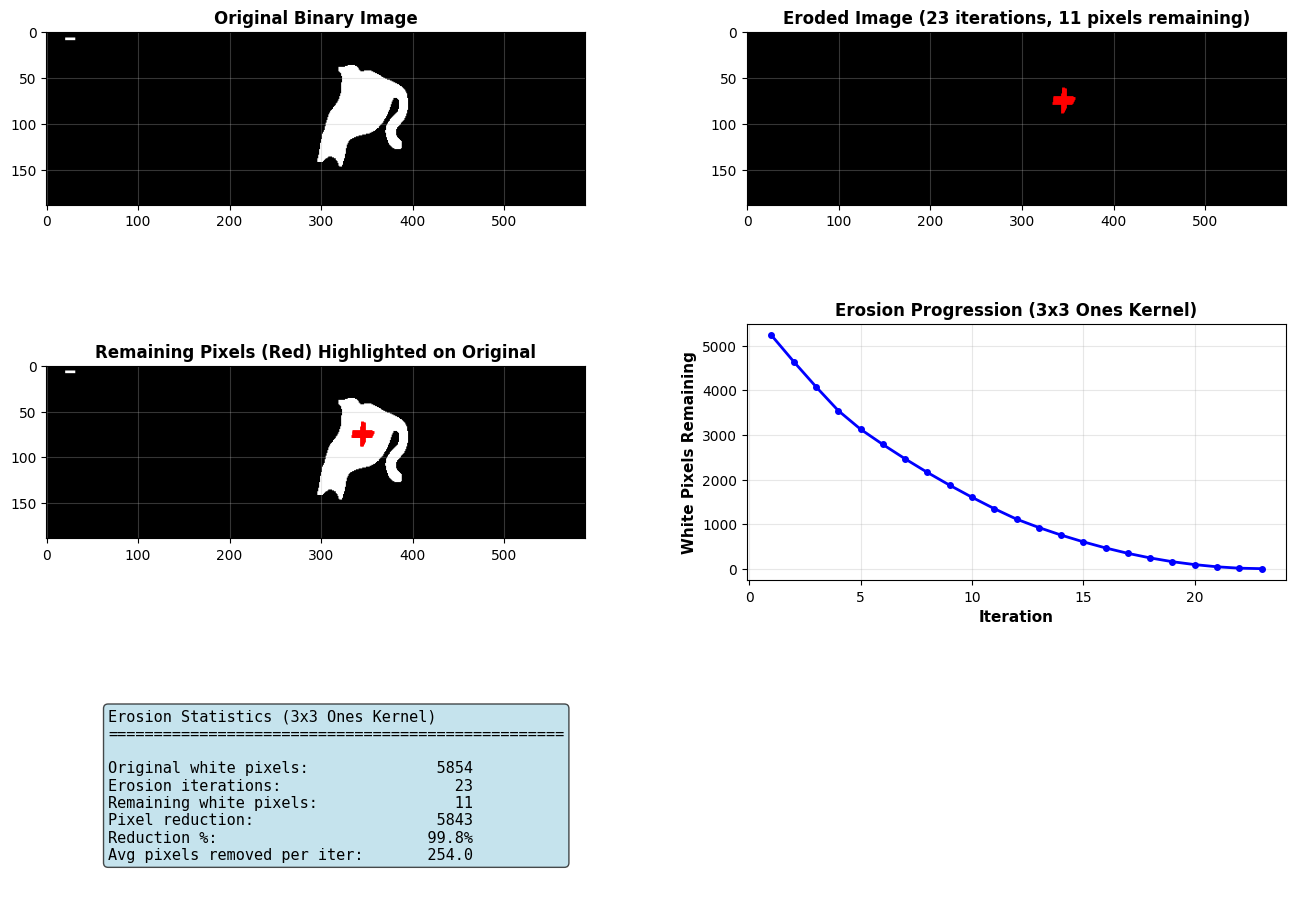

   Originale Weiß-Pixel : 5854
   Erosions-Iterationen : 23
   Verbleibende Pixel   : 0 (angezeigt: 11)
------------------------------------------------------------


In [71]:
# ── Alle JPG-Bilder aus dem Ordner laden, erodieren und visualisieren ──────────
import time

def erode_until_single_pixel_safe(binary_image):
    """
    Wie erode_until_single_pixel, speichert aber zusätzlich das vorletzte
    Erosionsergebnis. Falls die Erosion alle Pixel entfernt (0 übrig),
    wird das letzte Bild mit noch ≥1 Pixel zurückgegeben, damit die
    Visualisierung immer etwas anzeigen kann.

    Returns: (display_image, num_erosions, erosion_history, truly_remaining)
        display_image   – bestes Bild zur Anzeige (nie komplett leer)
        num_erosions    – tatsächliche Anzahl Erosionen
        erosion_history – wie gehabt
        truly_remaining – echte Anzahl verbleibender Pixel (kann 0 sein)
    """
    kernel = np.ones((3, 3), dtype=np.uint8)
    eroded = binary_image.copy()
    prev_eroded = binary_image.copy()   # vorletzte Stufe
    num_erosions = 0
    erosion_history = []

    while True:
        white_pixels_before = np.count_nonzero(eroded)
        if white_pixels_before == 0:
            break

        eroded_next = cv2.erode(eroded, kernel, iterations=1)
        num_erosions += 1
        white_pixels_after = np.count_nonzero(eroded_next)
        erosion_history.append((white_pixels_after, num_erosions))

        if white_pixels_after == 0:
            # Alle Pixel weg → vorletzte Stufe für Anzeige merken, dann abbrechen
            prev_eroded = eroded.copy()
            eroded = eroded_next
            break

        if white_pixels_after == 1:
            prev_eroded = eroded.copy()
            eroded = eroded_next
            break

        prev_eroded = eroded.copy()
        eroded = eroded_next

    truly_remaining = np.count_nonzero(eroded > 128)

    if truly_remaining > 0:
        display_image = eroded
    elif np.count_nonzero(prev_eroded > 128) > 0:
        display_image = prev_eroded
    else:
        # Letzter Ausweg: Original binarisiert anzeigen
        _, display_image = cv2.threshold(binary_image, 127, 255, cv2.THRESH_BINARY)

    # Sicherstellen dass display_image sauber binarisiert ist (JPEG-Artefakte vermeiden)
    _, display_image = cv2.threshold(display_image, 127, 255, cv2.THRESH_BINARY)

    return display_image, num_erosions, erosion_history, truly_remaining


# ── Hauptschleife ───────────────────────────────────────────────────────────────

image_dir = Path("../bin_image")          # <-- ggf. Pfad anpassen

jpg_files = sorted(image_dir.glob("*.jpg")) + sorted(image_dir.glob("*.JPG"))

if not jpg_files:
    print(f"Keine JPG-Dateien in '{image_dir}' gefunden.")
else:
    print(f"{len(jpg_files)} Bild(er) gefunden:\n" + "\n".join(f"  {p.name}" for p in jpg_files))
    print("=" * 60)

    for img_path in jpg_files:
        print(f"\n▶ Verarbeite: {img_path.name}")

        original_image = load_binary_image(img_path)
        # JPEG-Artefakte entfernen: sauber binarisieren
        _, original_image = cv2.threshold(original_image, 127, 255, cv2.THRESH_BINARY)

        # Zeitmessung: nur die reine Erosion
        t_start = time.perf_counter()
        display_image, num_erosions, erosion_history, truly_remaining = \
            erode_until_single_pixel_safe(original_image)
        t_elapsed = time.perf_counter() - t_start
        print(f"   ⏱ Erosionsdauer        : {t_elapsed * 1000:.2f} ms")

        # Hinweis wenn alle Pixel erodiert wurden
        if truly_remaining == 0:
            print(f"   ⚠ Alle Pixel erodiert – zeige letzten Zustand vor vollständiger Löschung.")

        # Immer visualisieren (display_image ist nie komplett leer)
        num_remaining = visualize_erosion_result(
            original_image, display_image, num_erosions, erosion_history
        )

        print(f"   Originale Weiß-Pixel : {np.count_nonzero(original_image)}")
        print(f"   Erosions-Iterationen : {num_erosions}")
        print(f"   Verbleibende Pixel   : {truly_remaining} (angezeigt: {num_remaining})")
        print("-" * 60)